# Plot SSS and upper ocean stratification - September

In [32]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
from pprint import pprint
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
import gsw
import cmocean
import matplotlib.patches as patches

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:39031")
client

<Client: 'tcp://127.0.0.1:39031' processes=8 threads=32, memory=123.95 GiB>

In [4]:
# initialize s3 filesystem
# for sassie s3 bucket
# s3_options = dict(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)
# for ecco s3 bucket
s3_options = dict(anon=False)

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [6]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open KPPhbl zarr store - [meters]
KPPdiffS_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/KPPdiffS_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

### Plot entire domain for reference

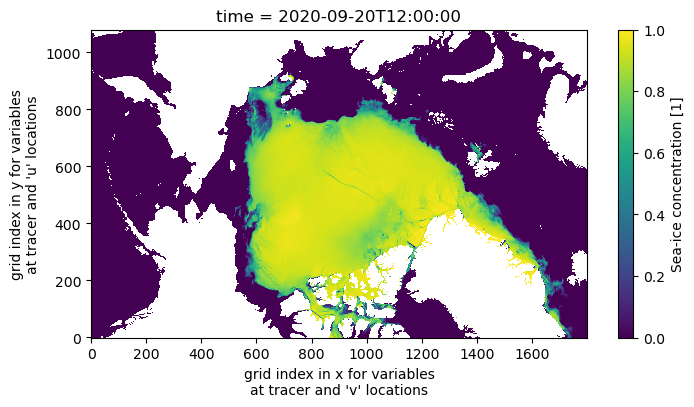

In [7]:
SI_zarr.SIarea.sel(time='2020-09-20').plot(figsize=[8,4]);

### Extract Beaufort Sea region and upper ocean

We're interested in the upper ~20 m and in the Beaufort Sea

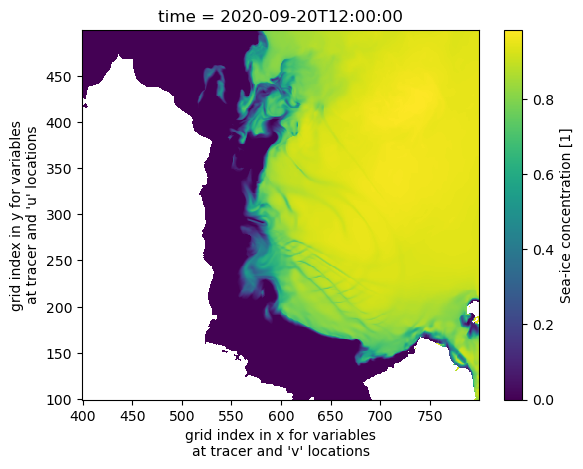

In [8]:
SI_zarr.SIarea.sel(time='2020-09-20').isel(i=slice(400,800),j=slice(100,500)).plot();

Only select upper 50 m

In [9]:
# selecting upper 50 m and Beaufort Sea
# one day: 2020
SALT_beaufort = SALT_zarr.sel(time='2020-09-20').isel(time=0,k=slice(0,16),i=slice(400,800),j=slice(100,500))
THETA_beaufort = THETA_zarr.sel(time='2020-09-20').isel(time=0,k=slice(0,16),i=slice(400,800),j=slice(100,500))

# select region for sea ice
SI_beaufort = SI_zarr.sel(time='2020').isel(i=slice(400,800),j=slice(100,500))

In [10]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")
beaufort_grid = HH_grid.isel(i=slice(400,800),j=slice(100,500),i_g=slice(400,800),j_g=slice(100,500),\
                             k=slice(0,16),k_l=slice(0,16),k_p1=slice(0,16),k_u=slice(0,16))

Use full profiles

In [11]:
# ENTIRE vertical profile and Beaufort Sea
# one day: 2020
SALT_beaufort = SALT_zarr.sel(time='2020-09-20').isel(time=0,i=slice(400,800),j=slice(100,500))
THETA_beaufort = THETA_zarr.sel(time='2020-09-20').isel(time=0,i=slice(400,800),j=slice(100,500))

# select region for sea ice
SI_beaufort = SI_zarr.sel(time='2020').isel(i=slice(400,800),j=slice(100,500))

In [12]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")
beaufort_grid = HH_grid.isel(i=slice(400,800),j=slice(100,500),i_g=slice(400,800),j_g=slice(100,500))

### Look at depth resolution of model

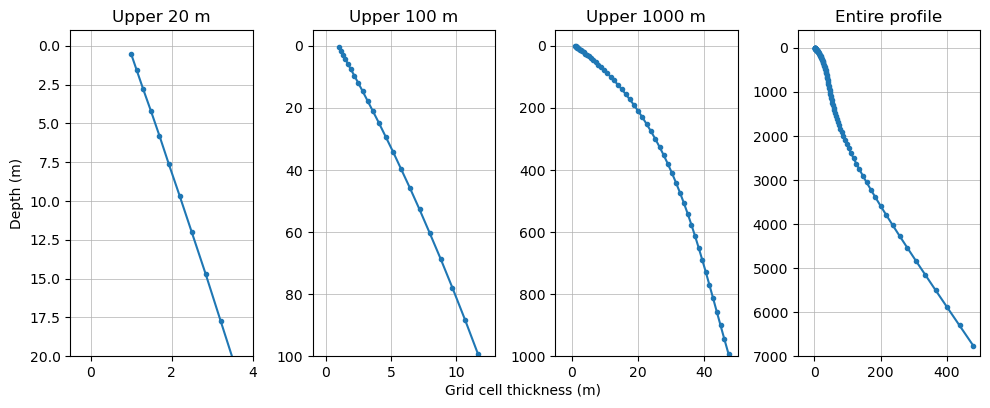

In [13]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4,figsize=[10,4])

ax1.plot(HH_grid.drF,HH_grid.Z*-1,marker='.')
ax2.plot(HH_grid.drF,HH_grid.Z*-1,marker='.')
ax3.plot(HH_grid.drF,HH_grid.Z*-1,marker='.')
ax4.plot(HH_grid.drF,HH_grid.Z*-1,marker='.')

# specify different limits
ax1.set_ylim(20,-1)
ax1.set_xlim(-0.5,4)
ax2.set_ylim(100,-5)
ax2.set_xlim(-1,13)
ax3.set_ylim(1000,-50)
ax3.set_xlim(-5,50)
ax4.set_ylim(7000,-400)
ax4.set_xlim(-50,500)

ax1.set_ylabel('Depth (m)')

ax1.grid(linewidth=0.5)
ax2.grid(linewidth=0.5)
ax3.grid(linewidth=0.5)
ax4.grid(linewidth=0.5)

ax1.set_title('Upper 20 m')
ax2.set_title('Upper 100 m')
ax3.set_title('Upper 1000 m')
ax4.set_title('Entire profile')

fig.text(0.45,0,'Grid cell thickness (m)')

plt.tight_layout()

### Calculate sea ice area and plot minimum

In [14]:
# select grid cell area
beaufort_area = beaufort_grid.rAc.load()

# calculate sea ice area
SIarea_sum_beaufort = (SI_beaufort.SIarea*beaufort_area).sum(dim=['j','i']).load()

In [15]:
# when did sea ice reach its minimum?
np.argmin(SIarea_sum_beaufort.values)

247

In [16]:
SI_min = SIarea_sum_beaufort.isel(time=247)
print(SI_min.time.values)

2020-09-04T12:00:00.000000000


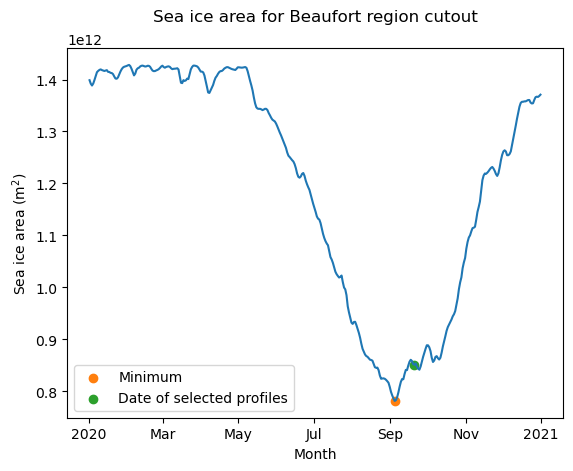

In [17]:
SIarea_sum_beaufort.plot();
plt.scatter(SI_min.time,SI_min.values,color='tab:orange',label='Minimum');
plt.scatter(SIarea_sum_beaufort.sel(time='2020-09-20').time,SIarea_sum_beaufort.sel(time='2020-09-20').values,color='tab:green',label='Date of selected profiles');
plt.title("Sea ice area for Beaufort region cutout",y=1.05)
plt.legend()
plt.ylabel("Sea ice area (m$^2$)")
plt.xlabel("Month");

### Calculate buoyancy frequency

Conversion functions: https://teos-10.github.io/GSW-Python/conversions.html

In [18]:
# conversion of practical salinity to absolute salinity
SA = gsw.SA_from_SP(SALT_beaufort.SALT, SALT_beaufort.Z, SALT_beaufort.XC, SALT_beaufort.YC)

# conversiotn of potential temperature (poTemp) to conservative temperature (CT)
CT = gsw.CT_from_pt(SA, THETA_beaufort.THETA)

# calculate pressure (dbar)
P = gsw.p_from_z(SALT_beaufort.Z, SALT_beaufort.YC)

In [19]:
# Brunt Vaisala Frequency (N^2)
# Buoyancy frequency-squared at pressure midpoints, 1/s^2. 
# The shape along the pressure axis dimension is one less than that of the inputs. (Frequency N is in radians per second.)
# Pressure at midpoints of p, dbar. The array shape matches N2.
N2, p_mid = gsw.Nsquared(SA, CT, P, SALT_beaufort.YC)

### Combine into one dataset

In [20]:
SA.name = 'salinity'
CT.name = 'temperature'

In [21]:
# take average across whole domain
p_mid_avg = p_mid.mean(axis=(1,2))

In [22]:
N2_da = xr.DataArray(data=N2,dims=['p_mid','j','i'],\
                     coords=dict(p_mid=p_mid_avg,j=SALT_beaufort.j.values,i=SALT_beaufort.i.values))

In [23]:
SA.name = 'salinity'
CT.name = 'temperature'

# add them to dataset
beaufort_ocean_ds = SALT_beaufort.copy(deep=True)

beaufort_ocean_ds['salinity'] = SA
beaufort_ocean_ds['temperature'] = CT
beaufort_ocean_ds = beaufort_ocean_ds.drop_vars('SALT')

# add buoyancy frequency
beaufort_ocean_ds.expand_dims(p_mid=p_mid_avg)
beaufort_ocean_ds['N2'] = N2_da

In [24]:
# add depth_mid
depth_mid = gsw.z_from_p(beaufort_ocean_ds.p_mid, beaufort_ocean_ds.YC.mean(dim=['j','i'])) 
depth_mid.name = 'depth_mid'

beaufort_ocean_ds = beaufort_ocean_ds.assign_coords(depth_mid=depth_mid*-1)
beaufort_ocean_ds = beaufort_ocean_ds.swap_dims({'p_mid':'depth_mid'})

### Plot SSS and N2, colored by T

In [25]:
land_mask = beaufort_grid.isel(k=0).maskC.astype(int)
land_mask = land_mask.where(land_mask==0,np.nan)

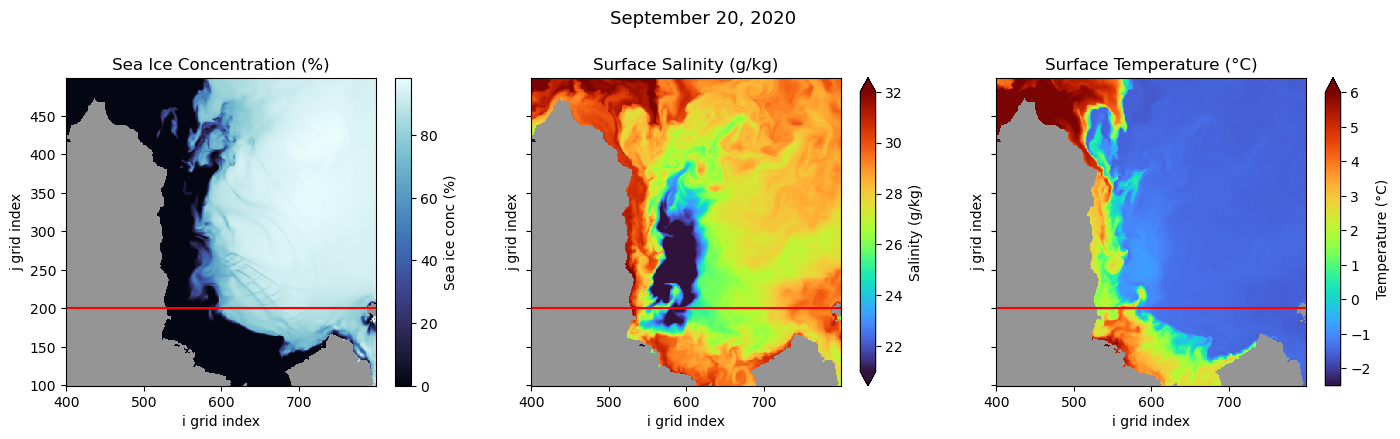

In [26]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[17,4],sharey=True,sharex=True)

(SI_beaufort.SIarea*100).sel(time='2020-09-20').plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
beaufort_ocean_ds.salinity.isel(k=0).plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
beaufort_ocean_ds.temperature.isel(k=0).plot(ax=ax3,cmap='turbo',vmin=-2.5,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});

for ax in (ax1,ax2,ax3):
    ax.axhline(y=200,color='r');
    land_mask.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("j grid index")
    ax.set_xlabel("i grid index")
    
ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");

plt.suptitle("September 20, 2020",y=1.05,fontsize=13);

In [27]:
# select all profiles in row 200
beaufort_ocean_ds_row = beaufort_ocean_ds.sel(j=200)
beaufort_ocean_ds_row = beaufort_ocean_ds_row.swap_dims({'k':'Z'})

In [28]:
beaufort_ocean_ds_row['Z'] = beaufort_ocean_ds_row['Z']*-1

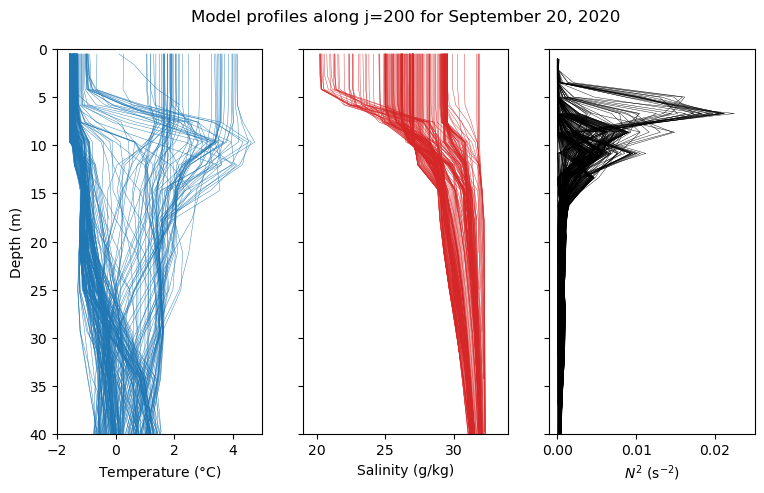

In [30]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[9,5])

# plot all underway ctd profiles
linewidth_size = 0.3

# temperature
beaufort_ocean_ds_row.temperature.plot(ax=ax1,y='Z',hue='i',c='tab:blue',add_legend=False,linewidth=linewidth_size)
# salinity
beaufort_ocean_ds_row.salinity.plot(ax=ax2,y='Z',hue='i',c='tab:red',add_legend=False,linewidth=linewidth_size)
# N2
beaufort_ocean_ds_row.N2.plot(ax=ax3,y='depth_mid',hue='i',c='k',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(40,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-2,5)
ax2.set_xlim(19,34)
ax3.set_xlim(-0.001,0.025)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$ (s$^{-2}$)")

ax2.set_title("Model profiles along j=200 for September 20, 2020",y=1.05);

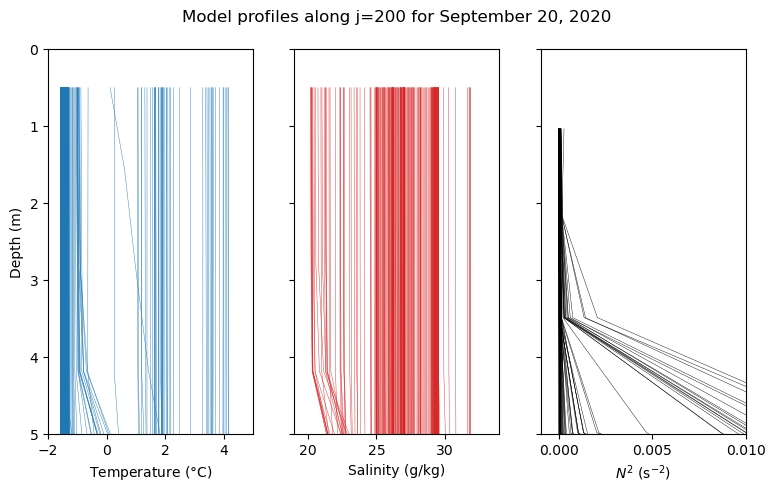

In [31]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[9,5])

# plot all underway ctd profiles
linewidth_size = 0.3

# temperature
beaufort_ocean_ds_row.temperature.plot(ax=ax1,y='Z',hue='i',c='tab:blue',add_legend=False,linewidth=linewidth_size)
# salinity
beaufort_ocean_ds_row.salinity.plot(ax=ax2,y='Z',hue='i',c='tab:red',add_legend=False,linewidth=linewidth_size)
# N2
beaufort_ocean_ds_row.N2.plot(ax=ax3,y='depth_mid',hue='i',c='k',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(5,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-2,5)
ax2.set_xlim(19,34)
ax3.set_xlim(-0.001,0.01)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$ (s$^{-2}$)")

ax2.set_title("Model profiles along j=200 for September 20, 2020",y=1.05);

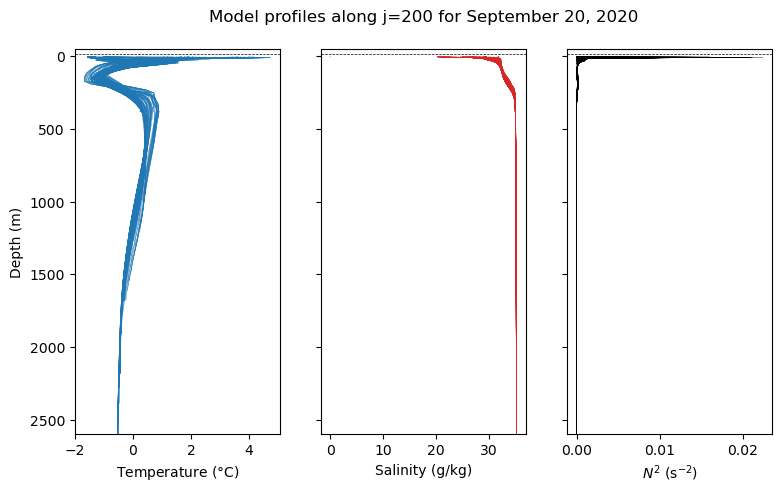

In [32]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[9,5])

# plot all underway ctd profiles
linewidth_size = 0.3

# temperature
beaufort_ocean_ds_row.temperature.plot(ax=ax1,y='Z',hue='i',c='tab:blue',add_legend=False,linewidth=linewidth_size)
# salinity
beaufort_ocean_ds_row.salinity.plot(ax=ax2,y='Z',hue='i',c='tab:red',add_legend=False,linewidth=linewidth_size)
# N2
beaufort_ocean_ds_row.N2.plot(ax=ax3,y='depth_mid',hue='i',c='k',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(2600,-50)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
# ax1.set_xlim(-2,5)
# ax2.set_xlim(19,34)
# ax3.set_xlim(-0.001,0.025)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$ (s$^{-2}$)")

ax2.set_title("Model profiles along j=200 for September 20, 2020",y=1.05);

In [33]:
beaufort_ocean_ds_row['N2_max'] = beaufort_ocean_ds_row.N2.max('depth_mid')

In [34]:
beaufort_ocean_ds_row_surface = beaufort_ocean_ds_row.isel(Z=0)

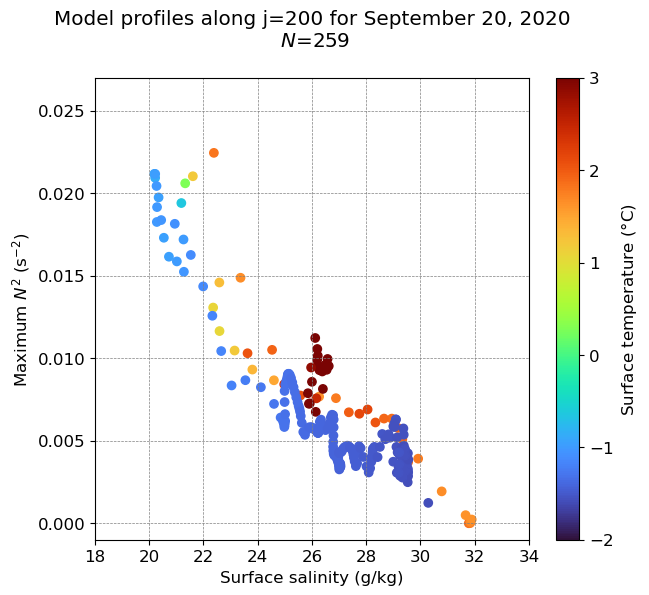

In [37]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(beaufort_ocean_ds_row_surface.salinity,beaufort_ocean_ds_row.N2_max,\
                       c=beaufort_ocean_ds_row_surface.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Maximum $N^2$ (s$^{-2}$)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-0.001,0.027)
ax.set_xlim(18,34)
N = len(beaufort_ocean_ds_row.N2_max[~np.isnan(beaufort_ocean_ds_row.N2_max)])
ax.set_title(f"Model profiles along j=200 for September 20, 2020\n $N$={N}",y=1.05);

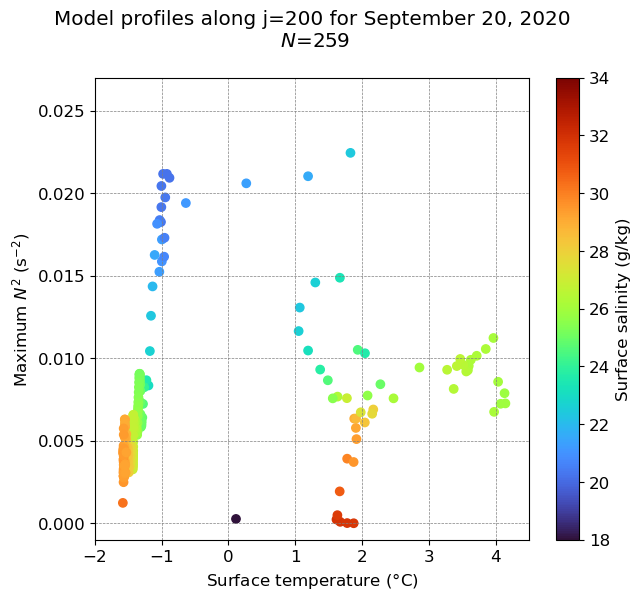

In [38]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(beaufort_ocean_ds_row_surface.temperature,beaufort_ocean_ds_row.N2_max,\
                       c=beaufort_ocean_ds_row_surface.salinity,cmap='turbo',vmin=18,vmax=34);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Maximum $N^2$ (s$^{-2}$)")
ax.set_xlabel("Surface temperature ($\degree$C)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface salinity (g/kg)');

ax.set_ylim(-0.001,0.027)
ax.set_xlim(-2,4.5)
N = len(beaufort_ocean_ds_row.N2_max[~np.isnan(beaufort_ocean_ds_row.N2_max)])
ax.set_title(f"Model profiles along j=200 for September 20, 2020\n $N$={N}",y=1.05);

### Mask out grid cells where sea ice is >15%

In [28]:
# select all grid cells in row 200
SI_day = (SI_beaufort.SIarea*100).sel(time='2020-09-20').isel(time=0)
SI_row = SI_day.sel(j=200)

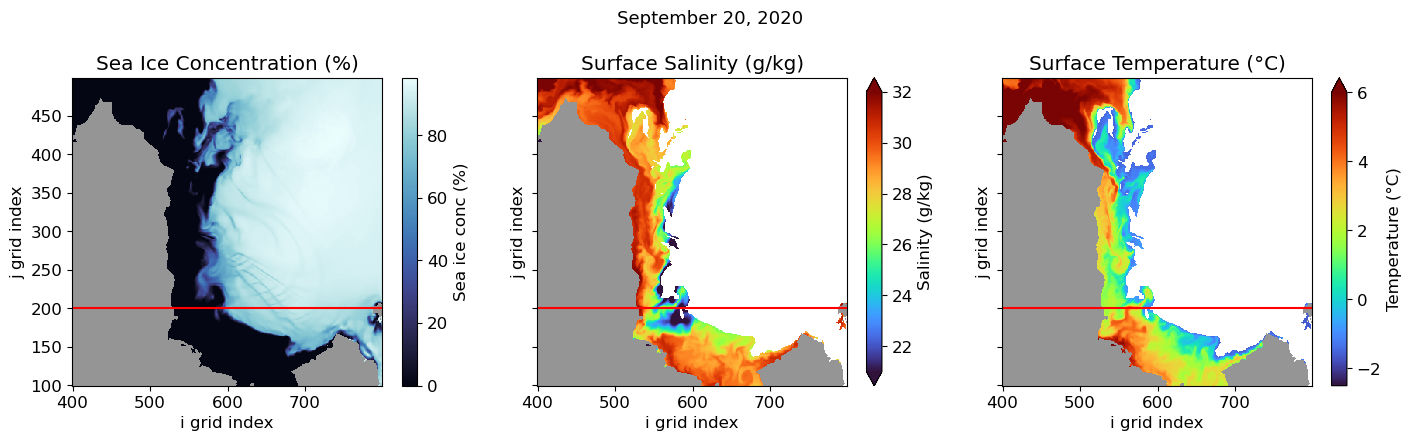

In [40]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[17,4],sharey=True,sharex=True)

(SI_beaufort.SIarea*100).sel(time='2020-09-20').plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
beaufort_ocean_ds.where(SI_day<15,np.nan).salinity.isel(k=0).plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot(ax=ax3,cmap='turbo',vmin=-2.5,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});

for ax in (ax1,ax2,ax3):
    ax.axhline(y=200,color='r');
    land_mask.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("j grid index")
    ax.set_xlabel("i grid index")
    
ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");

plt.suptitle("September 20, 2020",y=1.05,fontsize=13);

In [41]:
beaufort_ocean_ds_row_icefree = beaufort_ocean_ds_row.where(SI_row<15,np.nan)

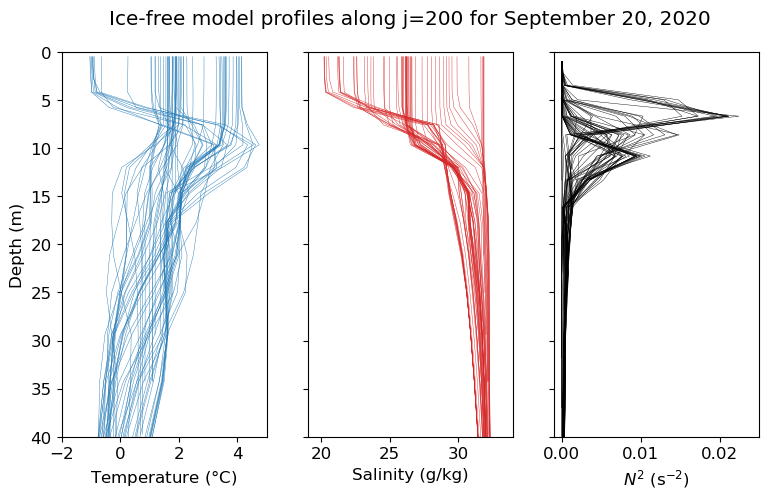

In [42]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[9,5])

# plot all underway ctd profiles
linewidth_size = 0.3

# temperature
beaufort_ocean_ds_row_icefree.temperature.plot(ax=ax1,y='Z',hue='i',c='tab:blue',add_legend=False,linewidth=linewidth_size)
# salinity
beaufort_ocean_ds_row_icefree.salinity.plot(ax=ax2,y='Z',hue='i',c='tab:red',add_legend=False,linewidth=linewidth_size)
# N2
beaufort_ocean_ds_row_icefree.N2.plot(ax=ax3,y='depth_mid',hue='i',c='k',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(40,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-2,5)
ax2.set_xlim(19,34)
ax3.set_xlim(-0.001,0.025)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$ (s$^{-2}$)")

ax2.set_title("Ice-free model profiles along j=200 for September 20, 2020",y=1.05);

In [43]:
beaufort_ocean_ds_row_icefree_surf = beaufort_ocean_ds_row_icefree.isel(Z=0)

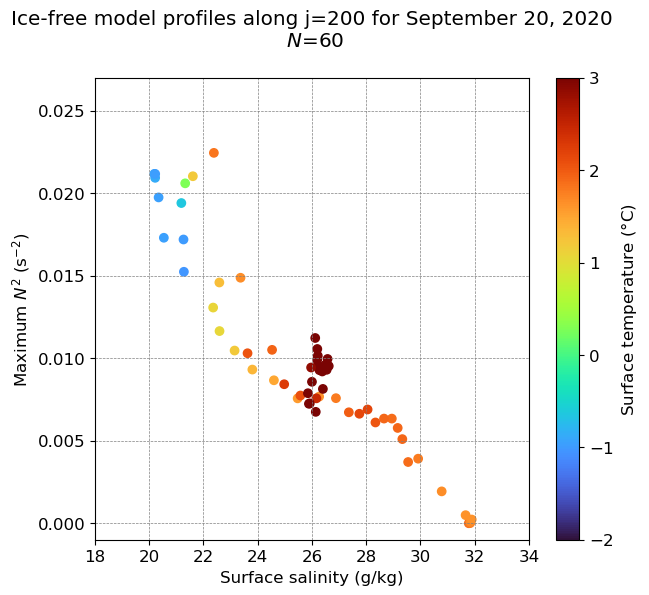

In [44]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(beaufort_ocean_ds_row_icefree_surf.salinity,beaufort_ocean_ds_row_icefree.N2_max,\
                       c=beaufort_ocean_ds_row_icefree_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Maximum $N^2$ (s$^{-2}$)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-0.001,0.027)
ax.set_xlim(18,34)

N = len(beaufort_ocean_ds_row_icefree.N2_max.values[~np.isnan(beaufort_ocean_ds_row_icefree.N2_max.values)])
ax.set_title(f"Ice-free model profiles along j=200 for September 20, 2020\n $N$={N}",y=1.05);

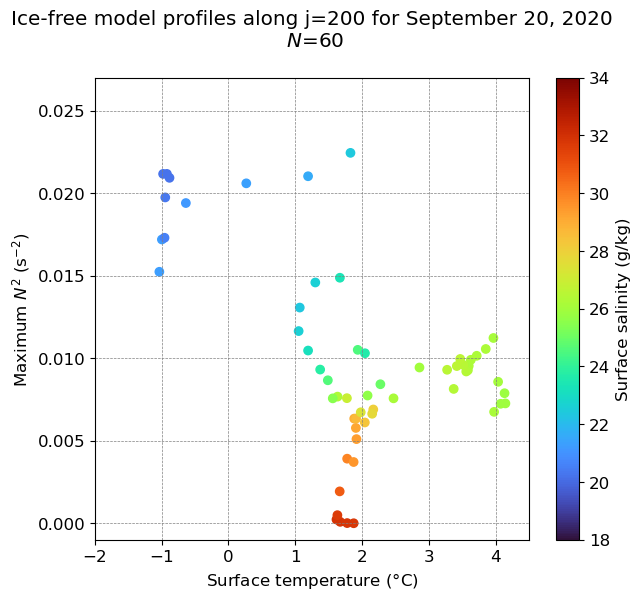

In [45]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(beaufort_ocean_ds_row_icefree_surf.temperature,beaufort_ocean_ds_row_icefree.N2_max,\
                       c=beaufort_ocean_ds_row_icefree_surf.salinity,cmap='turbo',vmin=18,vmax=34);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Maximum $N^2$ (s$^{-2}$)")
ax.set_xlabel("Surface temperature ($\degree$C)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface salinity (g/kg)');

ax.set_ylim(-0.001,0.027)
ax.set_xlim(-2,4.5)

N = len(beaufort_ocean_ds_row_icefree.N2_max.values[~np.isnan(beaufort_ocean_ds_row_icefree.N2_max.values)])
ax.set_title(f"Ice-free model profiles along j=200 for September 20, 2020\n $N$={N}",y=1.05);

### Then select a box of profiles in ice-free masked dataset

In [67]:
# select all grid cells in row 200
SI_day = (SI_beaufort.SIarea*100).sel(time='2020-09-20').isel(time=0)
SI_row = SI_day.sel(j=200)

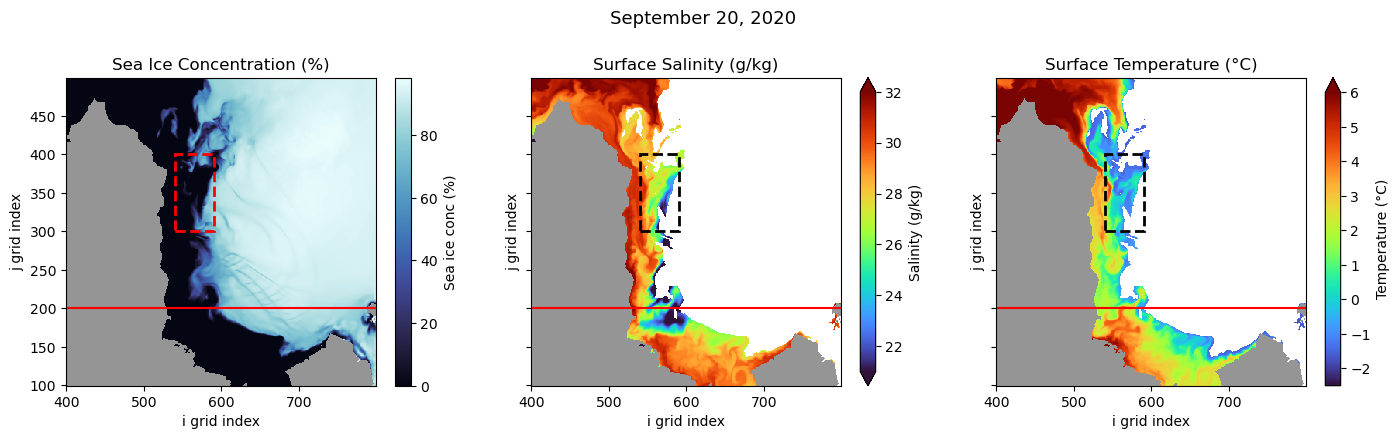

In [31]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[17,4],sharey=True,sharex=True)

(SI_beaufort.SIarea*100).sel(time='2020-09-20').plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
beaufort_ocean_ds.where(SI_day<15,np.nan).salinity.isel(k=0).plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot(ax=ax3,cmap='turbo',vmin=-2.5,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});

for ax in (ax1,ax2,ax3):
    ax.axhline(y=200,color='r');
    land_mask.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("j grid index")
    ax.set_xlabel("i grid index")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((540, 300), 50, 100, linewidth=2, edgecolor='r', linestyle='dashed', facecolor='none') # xy, width, height
ax1.add_patch(rect)
rect = patches.Rectangle((540, 300), 50, 100, linewidth=2, edgecolor='k', linestyle='dashed', facecolor='none') # xy, width, height
ax2.add_patch(rect)
rect = patches.Rectangle((540, 300), 50, 100, linewidth=2, edgecolor='k', linestyle='dashed', facecolor='none') # xy, width, height
ax3.add_patch(rect)

plt.suptitle("September 20, 2020",y=1.05,fontsize=13);

In [68]:
# remove ice covered grid cells
beaufort_ocean_ds_icefree = beaufort_ocean_ds.where(SI_day<15,np.nan)

# select profiles within box
sassie_box_ds = beaufort_ocean_ds_icefree.sel(i=slice(540,590),j=slice(300,400))

In [69]:
# make Z dimensional coordinate
sassie_box_ds = sassie_box_ds.swap_dims({'k':'Z'})

In [70]:
# make depth positive down
sassie_box_ds['Z'] = sassie_box_ds.Z*-1

In [71]:
# combine i, j coords
sassie_box_profiles_all = sassie_box_ds.stack(profile=("i", "j"))

In [72]:
# remove profiles that are all nan
sassie_box_profiles = sassie_box_profiles_all.dropna(dim='profile',how='all') # drop profiles where all vals are nan

In [73]:
# add N2 max
sassie_box_profiles['N2_max'] = sassie_box_profiles.N2.max('depth_mid')

In [74]:
# isolate depth at which N2 reaches max
N2_max_depth_nans = xr.where(sassie_box_profiles.N2_max==sassie_box_profiles.N2, sassie_box_profiles.depth_mid, np.nan)
N2_max_depth = N2_max_depth_nans.values[~N2_max_depth_nans.isnull()]

In [75]:
# add max N2 depth to ds
N2_max_depth_da = xr.DataArray(N2_max_depth, dims='profile')
sassie_box_profiles['N2_max_depth'] = N2_max_depth_da

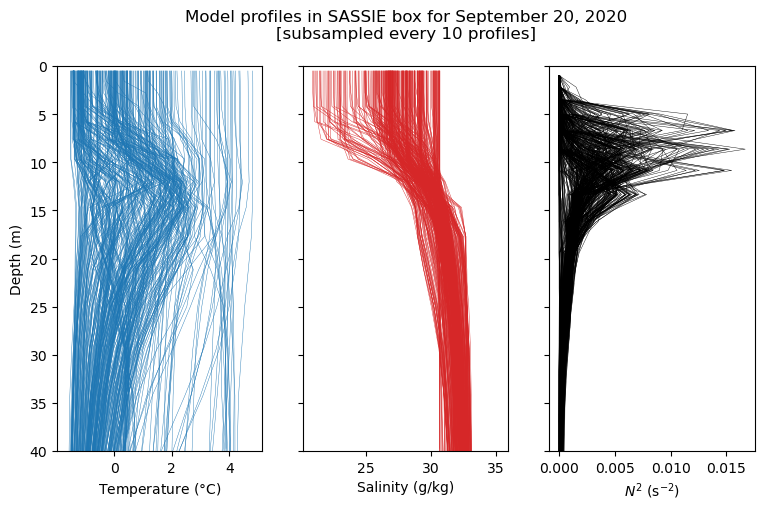

In [40]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[9,5])

# plot all underway ctd profiles
linewidth_size = 0.3

# temperature
sassie_box_profiles.temperature.isel(profile=slice(0, None, 10)).plot(ax=ax1,y='Z',c='tab:blue',hue='j',add_legend=False,linewidth=linewidth_size)
# salinity
sassie_box_profiles.salinity.isel(profile=slice(0, None, 10)).plot(ax=ax2,y='Z',c='tab:red',hue='j',add_legend=False,linewidth=linewidth_size)
# N2
sassie_box_profiles.isel(profile=slice(0, None, 10)).N2.plot(ax=ax3,y='depth_mid',c='k',hue='j',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(40,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
# ax1.set_xlim(-2,5)
# ax2.set_xlim(19,34)
# ax3.set_xlim(-0.001,0.025)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$ (s$^{-2}$)")

ax2.set_title("Model profiles in SASSIE box for September 20, 2020\n[subsampled every 10 profiles]",y=1.05);

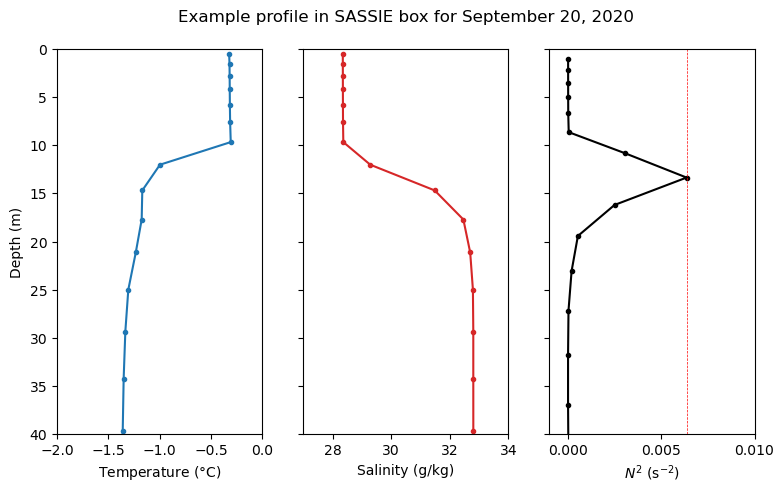

In [41]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[9,5])

# plot all underway ctd profiles
linewidth_size = 1.5

# temperature
sassie_box_profiles.temperature.isel(profile=100).plot(marker='.',ax=ax1,y='Z',c='tab:blue',hue='j',add_legend=False,linewidth=linewidth_size)
# salinity
sassie_box_profiles.salinity.isel(profile=100).plot(marker='.',ax=ax2,y='Z',c='tab:red',hue='j',add_legend=False,linewidth=linewidth_size)
# N2
sassie_box_profiles.isel(profile=100).N2.plot(marker='.',ax=ax3,y='depth_mid',c='k',hue='j',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(40,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")

# double check N2 max is right
ax3.axvline(x=sassie_box_profiles.isel(profile=100).N2_max.values,color='r',linestyle='dashed',linewidth=0.5)

# standardize x limits
ax1.set_xlim(-2,0)
ax2.set_xlim(27,34)
ax3.set_xlim(-0.001,0.01)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$ (s$^{-2}$)")

ax2.set_title("Example profile in SASSIE box for September 20, 2020",y=1.05);

In [76]:
sassie_box_profiles_surf = sassie_box_profiles.isel(Z=0)

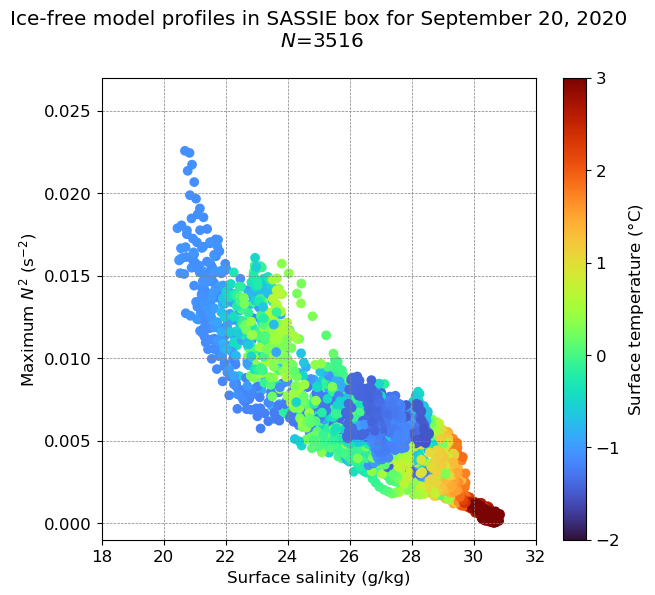

In [43]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sassie_box_profiles.N2_max,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Maximum $N^2$ (s$^{-2}$)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-0.001,0.027)
ax.set_xlim(18,32)

N = len(sassie_box_profiles.N2_max.values[~np.isnan(sassie_box_profiles.N2_max.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

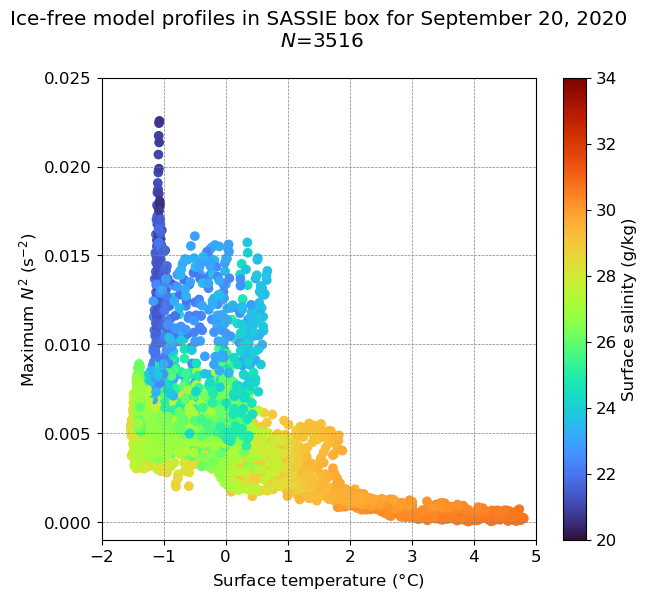

In [44]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.temperature,sassie_box_profiles.N2_max,\
                       c=sassie_box_profiles_surf.salinity,cmap='turbo',vmin=20,vmax=34);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Maximum $N^2$ (s$^{-2}$)")
ax.set_xlabel("Surface temperature ($\degree$C)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface salinity (g/kg)');

ax.set_ylim(-0.001,0.025)
ax.set_xlim(-2,5)

N = len(sassie_box_profiles.N2_max.values[~np.isnan(sassie_box_profiles.N2_max.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

Plot with depth of max N2

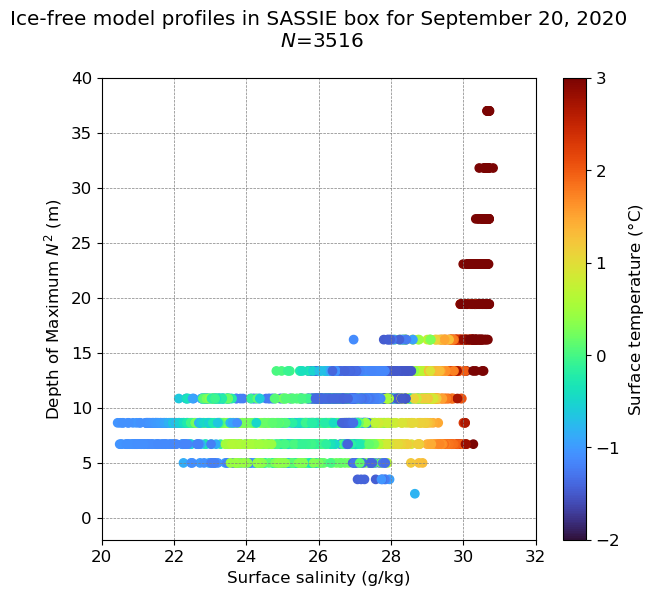

In [45]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sassie_box_profiles.N2_max_depth,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Depth of Maximum $N^2$ (m)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-2,40)
ax.set_xlim(20,32)

N = len(sassie_box_profiles.N2_max.values[~np.isnan(sassie_box_profiles.N2_max.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

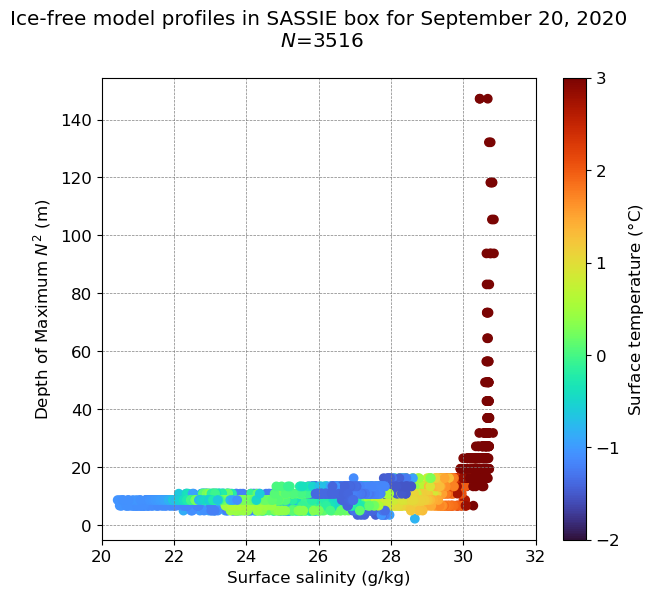

In [46]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sassie_box_profiles.N2_max_depth,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Depth of Maximum $N^2$ (m)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

# ax.set_ylim(-2,40)
ax.set_xlim(20,32)

N = len(sassie_box_profiles.N2_max.values[~np.isnan(sassie_box_profiles.N2_max.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

### Calculate mixed layer depth

Calculate mixed layer depth using a classic threshold method, then find max N2 within a vertical grid cell or two of that. Find the potential density at some shallow depth (with a model, it can just be the uppermost grid cell value), then find the uppermost depth where that potential density has increased by some increment ie "threshold" eg 0.1 kg/m3. EG see: https://www.sciencedirect.com/science/article/pii/S0079661114002158.

Load KPP

In [47]:
# for the boxed region
KPPdiffS_day = KPPdiffS_zarr.sel(time='2020-09-20',i=slice(540,590),j=slice(300,400)).isel(time=0).KPPdiffS

In [48]:
KPPdiffS_day = KPPdiffS_day.swap_dims({'k':'Z'})
KPPdiffS_day['Z'] = KPPdiffS_day.Z*-1

#### Calculate potential Density

Pressure from Z

In [49]:
# Z needs to be positive up
pressure_da = gsw.conversions.p_from_z(sassie_box_profiles.Z*-1,\
                                       sassie_box_profiles.YC,\
                                       geo_strf_dyn_height=0, sea_surface_geopotential=0)

Absolute Salinity

In [50]:
# Calculates Absolute Salinity from Practical Salinity
SA = gsw.conversions.SA_from_SP(sassie_box_profiles.salinity, pressure_da,\
                                sassie_box_profiles.XC, sassie_box_profiles.YC)

Conservative Temperature

In [51]:
# Calculates Conservative Temperature of seawater from potential temperature (whose reference sea pressure is zero dbar)
CT = gsw.conversions.CT_from_pt(SA, sassie_box_profiles.temperature)

In [52]:
# calculate potential density
density = gsw.density.sigma0(SA, CT)

Add density to dataset

In [53]:
density.name = 'potential_density'
sassie_box_profiles['density'] = density
sassie_box_profiles['density'].attrs['long_name'] = 'potential_density'
sassie_box_profiles['density'].attrs['units'] = 'kg m^-3'
sassie_box_profiles['density'].attrs['standard_name'] = 'potential_density'
sassie_box_profiles['density'].attrs['comment'] = ''

#### Calculate MLD using $\Delta\rho$

In [54]:
# identify the maximum depth at which the density is within a certain threshold of the shallowest measured density 
# take density from uppermost grid cell
rho_Z0 = sassie_box_profiles.isel(Z=0).density

In [55]:
# add threshold
density_threshold = 0.1 # kg m^-3
threshold = (rho_Z0 + density_threshold).values

In [56]:
# subtract threshold from density profiles
density_minus_threshold = abs(sassie_box_profiles.density-threshold)

In [57]:
# identify index for where density exceeds threshold
# need to go one grid cell down to get the big jump to match with N2
threshold_idx = density_minus_threshold.argmin(dim='Z',skipna=True) + 1

In [58]:
# extract depth where density exceeds threshold (=MLD)
MLD_profiles = sassie_box_profiles.isel(Z=threshold_idx.compute()).Z

In [59]:
# extract N2 at bottom of mixed layer
MLD_N2 = sassie_box_profiles.isel(depth_mid=threshold_idx.compute()).N2

In [60]:
# extract depth of N2 at MLD
MLD_N2_depth = sassie_box_profiles.isel(depth_mid=threshold_idx.compute()).depth_mid

Add these to ds

In [61]:
MLD_profiles.name = 'MLD'
sassie_box_profiles['MLD'] = MLD_profiles

In [62]:
MLD_N2.name = 'MLD_N2'
sassie_box_profiles['MLD_N2'] = MLD_N2

In [63]:
MLD_N2_depth.name = 'MLD_N2_depth'
sassie_box_profiles['MLD_N2_depth'] = MLD_N2_depth

#### figure out where MLD_N2 is nan

In [64]:
nan_indices = np.where(np.isnan(sassie_box_profiles.MLD_N2.values))

In [65]:
nan_indices

(array([ 64,  65,  66, 164, 165, 166, 263, 264, 265, 364]),)

#### Plot

In [84]:
def plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,prof_idx=100):
    
    fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5,sharey=True,figsize=[10,5])
    
    i_idx = sassie_box_profiles.temperature.isel(profile=prof_idx).i.values
    j_idx = sassie_box_profiles.temperature.isel(profile=prof_idx).j.values
    KPPdiffS_day_profile = KPPdiffS_day.sel(j=j_idx,i=i_idx)
    
    # plot all underway ctd profiles
    linewidth_size = 1.2
    
    # temperature
    sassie_box_profiles.temperature.isel(profile=prof_idx).plot(ax=ax1,marker='.',y='Z',c='tab:blue',add_legend=False,linewidth=linewidth_size)
    # salinity
    sassie_box_profiles.salinity.isel(profile=prof_idx).plot(ax=ax2,marker='.',y='Z',c='tab:red',add_legend=False,linewidth=linewidth_size)
    # N2
    sassie_box_profiles.isel(profile=prof_idx).N2.plot(ax=ax3,marker='.',y='depth_mid',c='k',add_legend=False,linewidth=linewidth_size)
    # KPPdiffS
    KPPdiffS_day_profile.plot(ax=ax4,marker='.',y='Z',c='k',add_legend=False,linewidth=linewidth_size)
    # potential density
    sassie_box_profiles.density.isel(profile=prof_idx).plot(ax=ax5,marker='.',y='Z',c='k',add_legend=False,linewidth=linewidth_size)

    # calculate max depth of profile
    max_depth = int(sassie_box_profiles.Z.values[~np.isnan(sassie_box_profiles.temperature.isel(profile=prof_idx).values)][-1])

    # pull out MLD
    MLD = sassie_box_profiles.isel(profile=prof_idx).MLD.values
    
    # add point for N2 just below MLD
    MLD_N2 = sassie_box_profiles.isel(profile=prof_idx).MLD_N2.values
    MLD_N2_depth = sassie_box_profiles.isel(profile=prof_idx).MLD_N2_depth.values
    ax3.plot(MLD_N2,MLD_N2_depth,color='r',marker='D',zorder=6)
    
    for ax in (ax1,ax2,ax3,ax4,ax5):
        # ax.set_ylim(40,-2)
        ax.set_ylim(max_depth+5,-2)
        # ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title("")
        ax.axhline(y=MLD,linewidth=0.5,color='gray')
    
    # double check N2 max is right
    # ax3.axvline(x=sassie_box_profiles.isel(profile=prof_idx).N2_max.values,color='r',linestyle='dashed',linewidth=0.5)
    
    # standardize x limits
    # ax1.set_xlim(-2,0)
    # ax2.set_xlim(27,34)
    # ax3.set_xlim(-0.001,0.01)
    
    ax1.set_ylabel("Depth (m)")
    ax1.set_xlabel("Temperature ($\degree$C)")
    ax2.set_xlabel("Salinity (g/kg)")
    ax3.set_xlabel("$N^2$ (s$^{-2}$)")
    ax4.set_xlabel("KPPdiffS")
    ax5.set_xlabel("Density (kg m$^{-3}$)")
    plt.tight_layout()
    plt.suptitle("Example profile in SASSIE box for September 20, 2020",y=1.05,x=0.5);

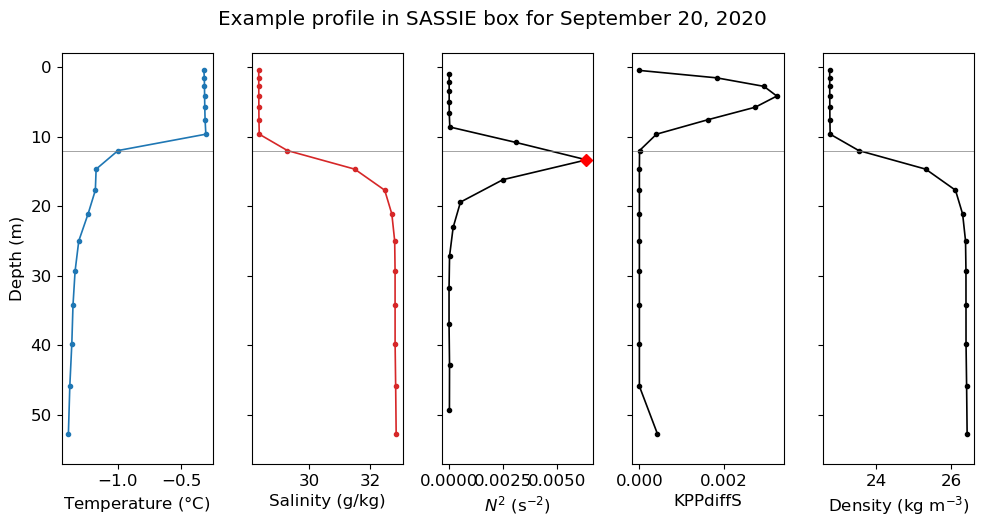

In [359]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,100)

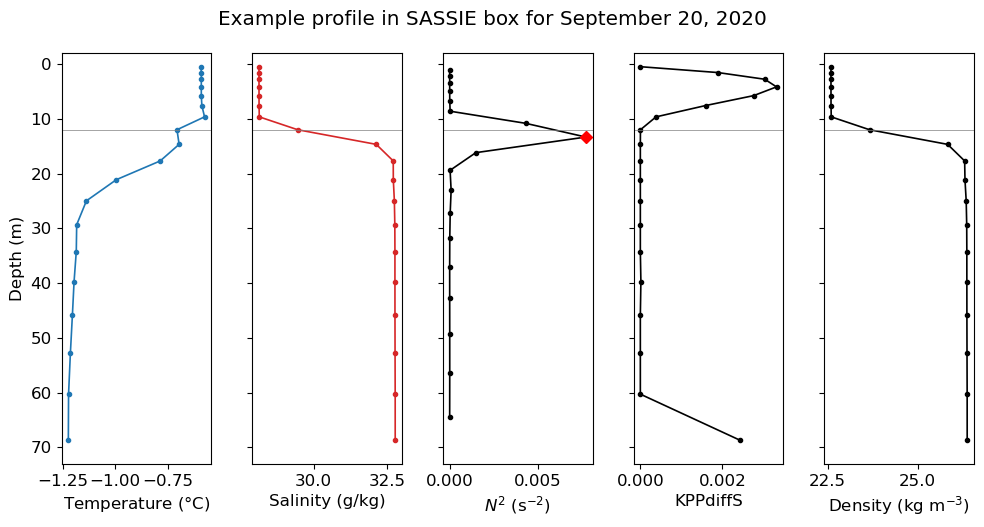

In [360]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,1000)

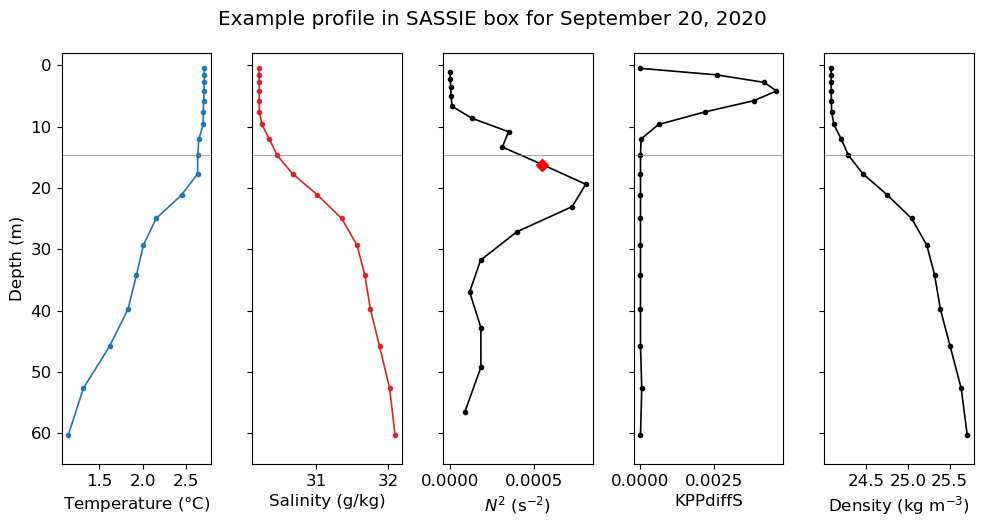

In [361]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,20)

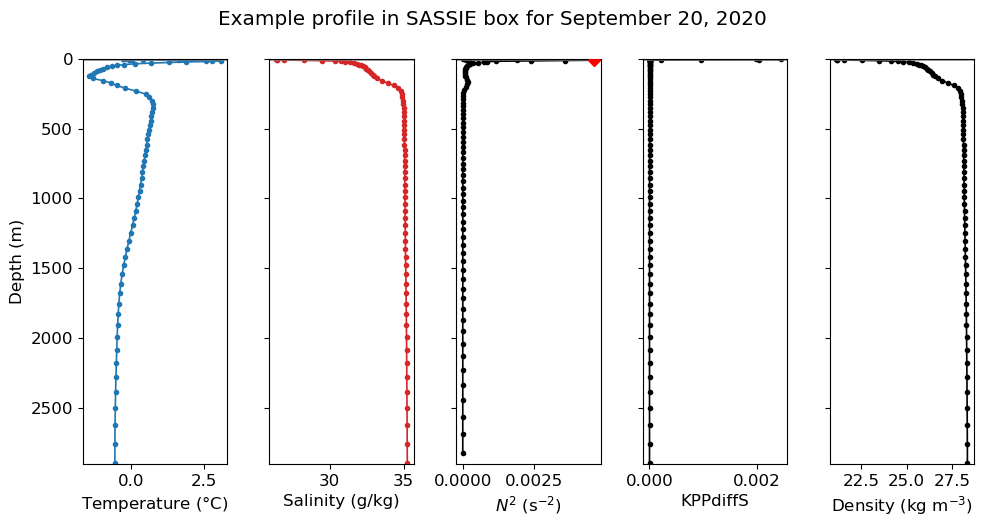

In [364]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,2000)

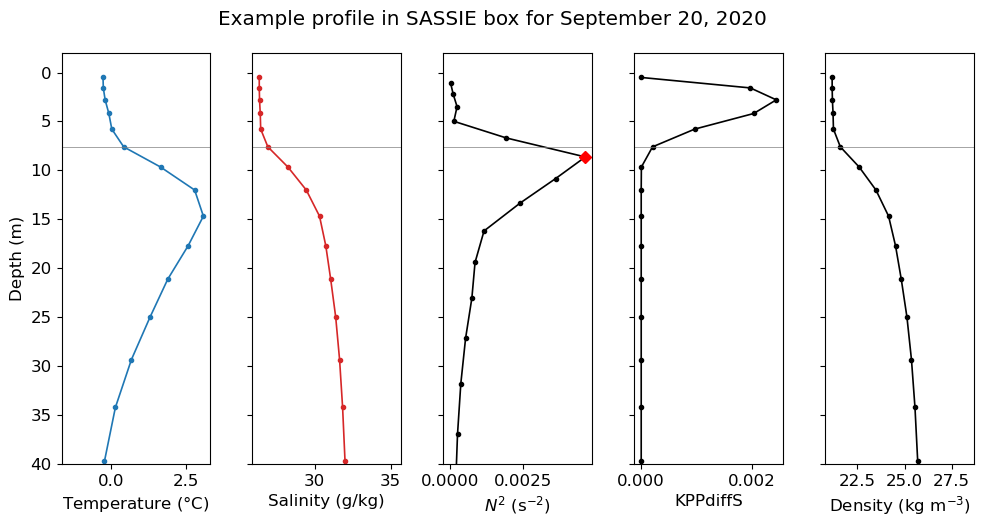

In [366]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,2000)

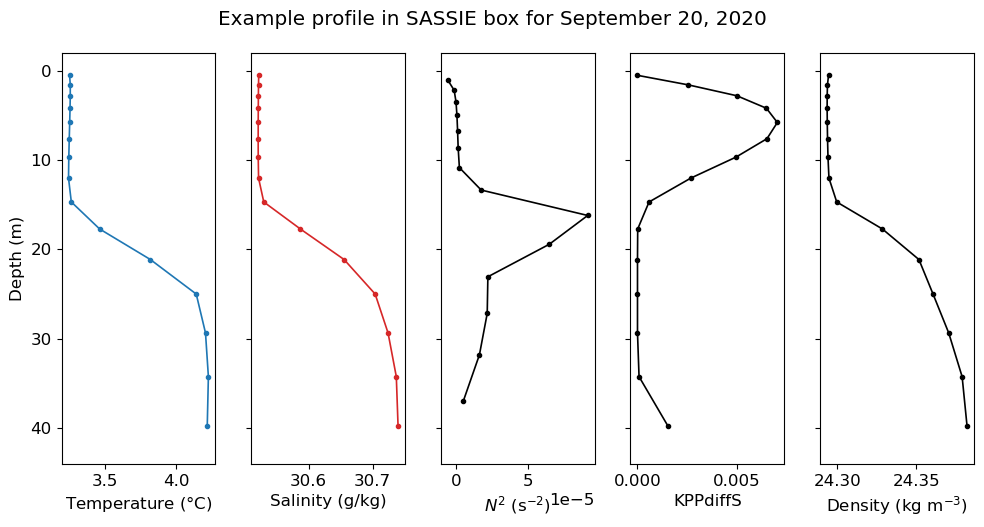

In [387]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,64)

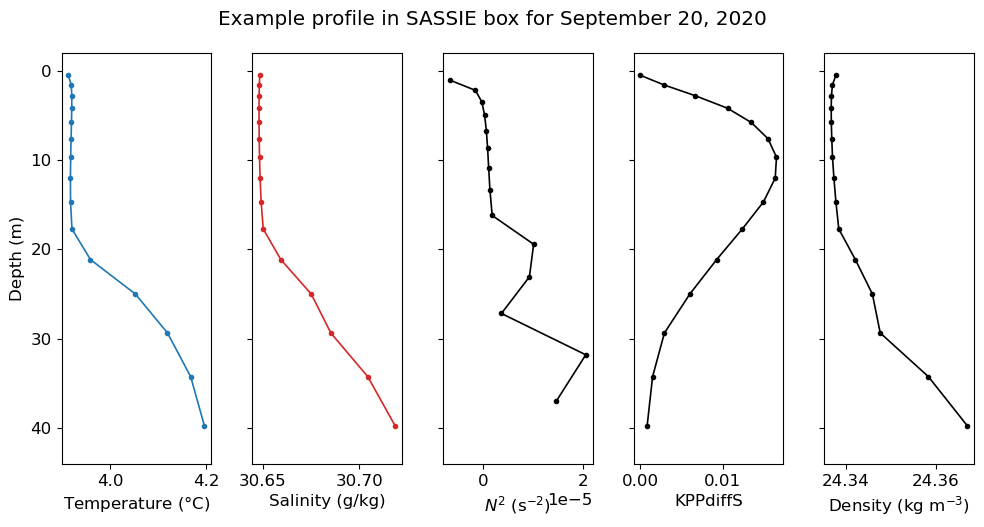

In [388]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,65)

In [389]:
sassie_box_profiles.MLD.isel(profile=65).values

array(45.855, dtype=float32)

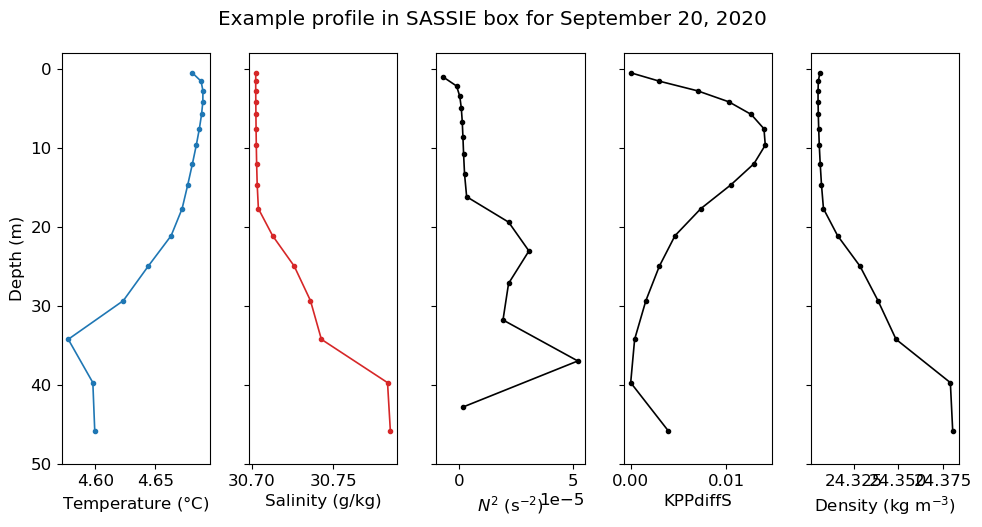

In [390]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,265)

## Now plot profiles from Beaufort sea region using MLD metrics

#### SSS vs MLD

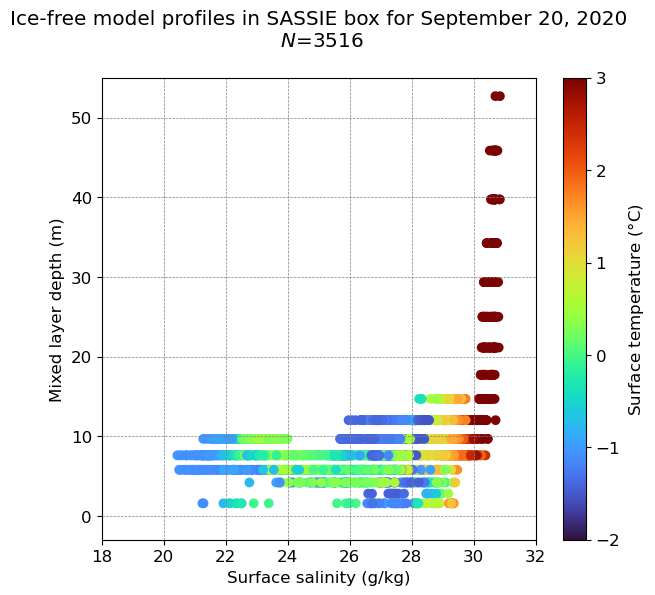

In [66]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sassie_box_profiles.MLD,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("Mixed layer depth (m)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-3,55)
ax.set_xlim(18,32)

N = len(sassie_box_profiles.MLD.values[~np.isnan(sassie_box_profiles.MLD.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

#### SSS vs N2 just below MLD

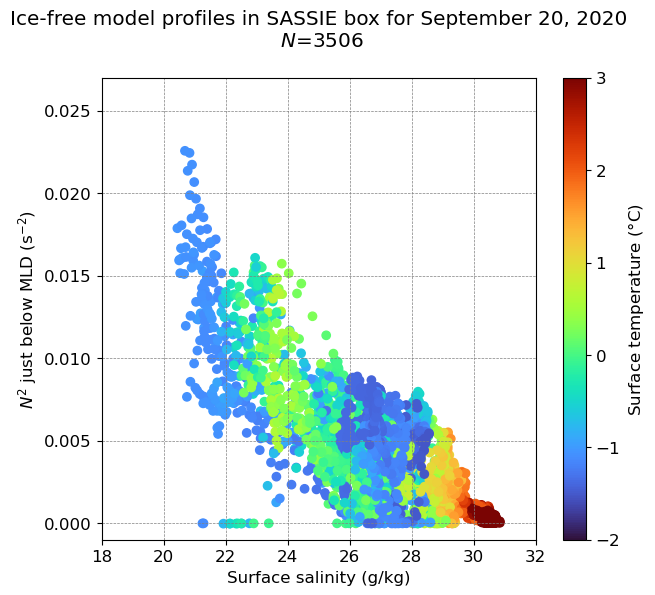

In [67]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sassie_box_profiles.MLD_N2,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel("$N^2$ just below MLD (s$^{-2}$)")
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-0.001,0.027)
ax.set_xlim(18,32)

N = len(sassie_box_profiles.MLD_N2.values[~np.isnan(sassie_box_profiles.MLD_N2.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

#### SSS vs depth of N2 just below MLD

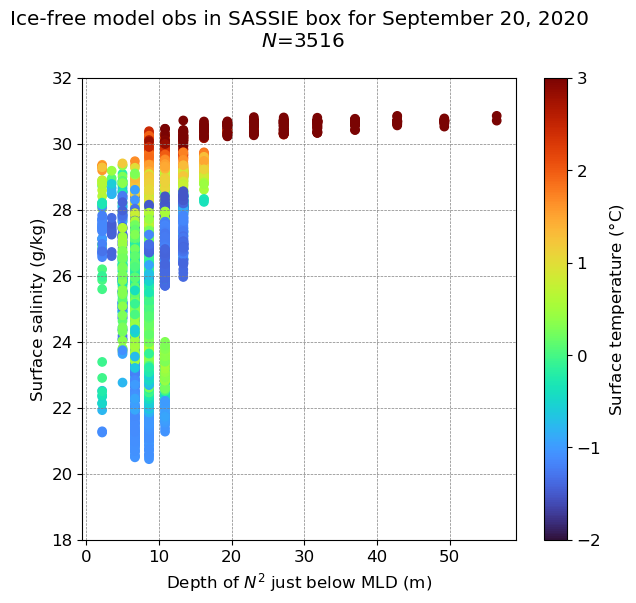

In [355]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles.MLD_N2_depth,sassie_box_profiles_surf.salinity,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=3);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_xlabel("Depth of $N^2$ just below MLD (m)")
ax.set_ylabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

# ax.set_xlim(-0.001,0.027)
ax.set_ylim(18,32)

N = len(sassie_box_profiles.MLD_N2_depth.values[~np.isnan(sassie_box_profiles.MLD_N2_depth.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

## Plot $\sum N$ over upper 20 m

In [77]:
# calculate sum of N in upper 20 meters

# check depth range
print(sassie_box_profiles.isel(depth_mid=slice(0,10)).depth_mid.values)

# select N2 values in this range, square root, and then take sum
sum_N_upper20m = np.sqrt(sassie_box_profiles.isel(depth_mid=slice(0,10)).N2.sum('depth_mid'))

[ 1.03498123  2.17995986  3.48743546  4.98240779  6.68737606  8.62733993
 10.83479934 13.34475328 16.19220073 19.41464144]


In [81]:
sum_N2_upper20m = sassie_box_profiles.isel(depth_mid=slice(0,10)).N2.sum('depth_mid')

In [85]:
sum_N2_upper20m_neg = sum_N2_upper20m.where((sum_N2_upper20m<0).compute(),drop=True)

In [87]:
sum_N2_upper20m_neg.values

array([-3.05462188e-06, -1.24320997e-07, -9.11942867e-06, -1.27050257e-05,
       -1.18689100e-05, -5.81962716e-06, -4.81610155e-06, -6.46294965e-06])

### Find profiles where N2 is negative

In [114]:
def plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,prof_num=(541, 356)):
    """
    Uses profile multindex e.g., (100,201) as opposed to the profile index e.g., 10
    """
    fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5,sharey=True,figsize=[10,5])
    
    i_idx = sassie_box_profiles.temperature.sel(profile=prof_num).i.values
    j_idx = sassie_box_profiles.temperature.sel(profile=prof_num).j.values
    KPPdiffS_day_profile = KPPdiffS_day.sel(j=j_idx,i=i_idx)
    
    # plot all underway ctd profiles
    linewidth_size = 1.2
    
    # temperature
    sassie_box_profiles.temperature.sel(profile=prof_num).plot(ax=ax1,marker='.',y='Z',c='tab:blue',add_legend=False,linewidth=linewidth_size)
    # salinity
    sassie_box_profiles.salinity.sel(profile=prof_num).plot(ax=ax2,marker='.',y='Z',c='tab:red',add_legend=False,linewidth=linewidth_size)
    # N2
    sassie_box_profiles.sel(profile=prof_num).N2.plot(ax=ax3,marker='.',y='depth_mid',c='k',add_legend=False,linewidth=linewidth_size)
    # KPPdiffS
    KPPdiffS_day_profile.plot(ax=ax4,marker='.',y='Z',c='k',add_legend=False,linewidth=linewidth_size)
    # potential density
    sassie_box_profiles.density.sel(profile=prof_num).plot(ax=ax5,marker='.',y='Z',c='k',add_legend=False,linewidth=linewidth_size)

    # calculate max depth of profile
    max_depth = int(sassie_box_profiles.Z.values[~np.isnan(sassie_box_profiles.temperature.sel(profile=prof_num).values)][-1])

    # pull out MLD
    MLD = sassie_box_profiles.sel(profile=prof_num).MLD.values
    
    # add point for N2 just below MLD
    MLD_N2 = sassie_box_profiles.sel(profile=prof_num).MLD_N2.values
    MLD_N2_depth = sassie_box_profiles.sel(profile=prof_num).MLD_N2_depth.values
    ax3.plot(MLD_N2,MLD_N2_depth,color='r',marker='D',zorder=6,label='N2 below MLD')

    # add vertical grid line at zero
    ax3.axvline(x=0,linewidth=0.5,color='gray',linestyle='dashed')
    
    for ax in (ax1,ax2,ax3,ax4,ax5):
        # ax.set_ylim(40,-2)
        ax.set_ylim(max_depth+5,-2)
        # ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title("")
        ax.axhline(y=MLD,linewidth=1,color='gray',label='MLD')
    
    # double check N2 max is right
    # ax3.axvline(x=sassie_box_profiles.isel(profile=prof_idx).N2_max.values,color='r',linestyle='dashed',linewidth=0.5)
    
    # standardize x limits
    # ax1.set_xlim(-2,0)
    # ax2.set_xlim(27,34)
    ax3.set_xlim(-0.00001,0.00001)
    ax5.set_xlim(24.14,24.16)
    ax3.legend(fontsize=8)
    # ax5.legend()
    
    ax1.set_ylabel("Depth (m)")
    ax1.set_xlabel("Temperature ($\degree$C)")
    ax2.set_xlabel("Salinity (g/kg)")
    ax3.set_xlabel("$N^2$ (s$^{-2}$)")
    ax4.set_xlabel("KPPdiffS")
    ax5.set_xlabel("Density (kg m$^{-3}$)")
    plt.tight_layout()
    plt.suptitle("Example profile in SASSIE box for September 20, 2020 (ZOOMED N2 AND DENSITY)",y=1.05,x=0.5);

In [76]:
# figure out where profiles are negative and take a look at them
sum_N2_upper20m = sassie_box_profiles.isel(depth_mid=slice(0,10)).N2.sum('depth_mid')

sum_N2_upper20m_neg = sum_N2_upper20m.where((sum_N2_upper20m<0).compute(),drop=True)

In [91]:
# print out the profile Multi-indexes
sum_N2_upper20m_neg.profile.values

array([(541, 356), (541, 364), (542, 342), (543, 344), (543, 345),
       (543, 349), (543, 350), (544, 353)], dtype=object)

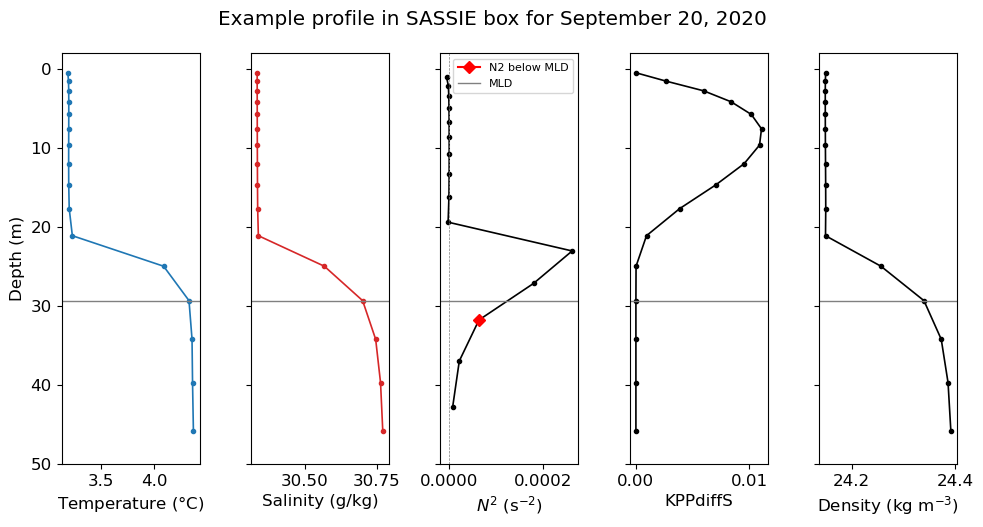

In [103]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,(541, 356))

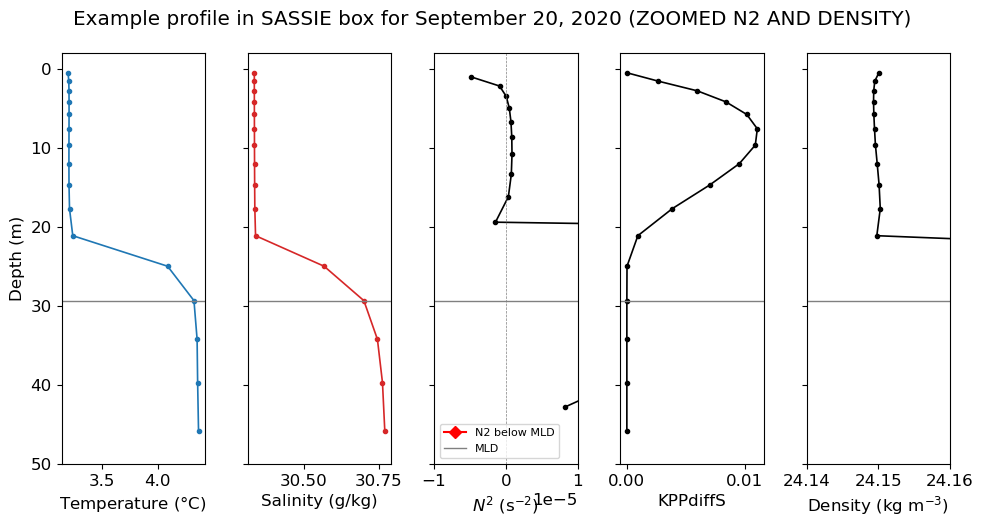

In [115]:
plot_profiles_gridcell(sassie_box_profiles,KPPdiffS_day,(541, 356))

## Plot SSS and sum(N) in upper 20

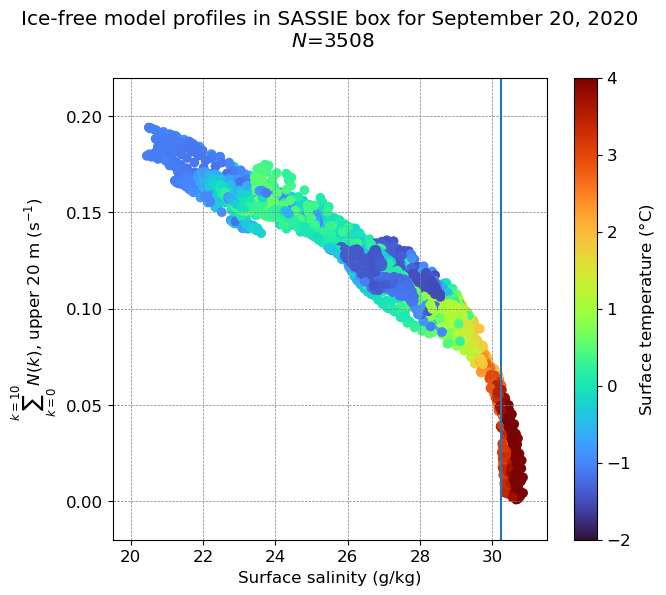

In [88]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sum_N_upper20m,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=4);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel(r'$\sum_{k=0}^{k=10} N(k)$, upper 20 m (s$^{-1}$)')
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-0.02,0.22)
ax.set_xlim(19.5,31.5)
ax.axvline(x=30.25)

N = len(sum_N_upper20m.values[~np.isnan(sum_N_upper20m.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

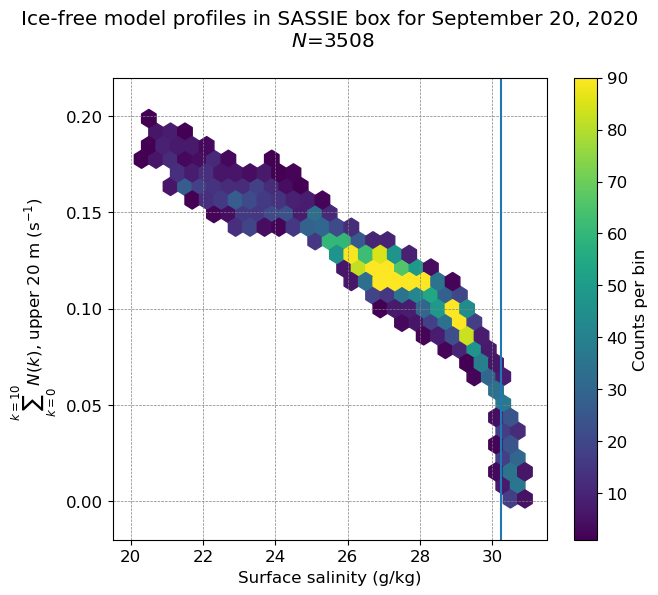

In [93]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

extent = [19.5,31.5,-0.02,0.22]
cbar_temp = ax.hexbin(sassie_box_profiles_surf.salinity,sum_N_upper20m, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=90)

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel(r'$\sum_{k=0}^{k=10} N(k)$, upper 20 m (s$^{-1}$)')
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Counts per bin');

ax.set_ylim(-0.02,0.22)
ax.set_xlim(19.5,31.5)
ax.axvline(x=30.25)

N = len(sum_N_upper20m.values[~np.isnan(sum_N_upper20m.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

## Plot $\sum N$ over upper 100 m

In [89]:
# calculate sum of N in upper 100 meters

# check depth range
print(sassie_box_profiles.isel(depth_mid=slice(0,22)).depth_mid.values)

# select N2 values in this range, square root, and then take sum
sum_N_upper105m = np.sqrt(sassie_box_profiles.isel(depth_mid=slice(0,22)).N2.sum('depth_mid'))

[  1.03498123   2.17995986   3.48743546   4.98240779   6.68737606
   8.62733993  10.83479934  13.34475328  16.19220073  19.41464144
  23.05707474  27.16699945  31.79191635  36.98182192  42.78921606
  49.27159963  56.48397006  64.48132687  73.32366857  83.06849885
  93.77081336 105.48310528]


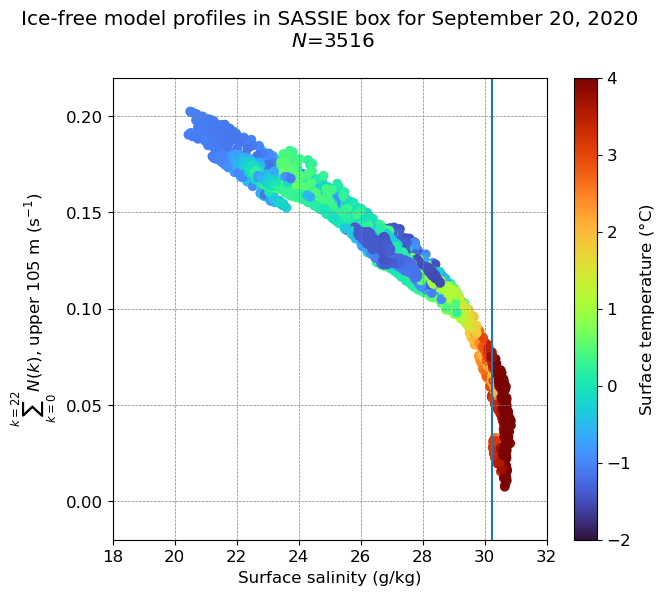

In [90]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf.salinity,sum_N_upper105m,\
                       c=sassie_box_profiles_surf.temperature,cmap='turbo',vmin=-2,vmax=4);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel(r'$\sum_{k=0}^{k=22} N(k)$, upper 105 m (s$^{-1}$)')
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(-0.02,0.22)
ax.set_xlim(18,32)
ax.axvline(x=30.25)

N = len(sum_N_upper105m.values[~np.isnan(sum_N_upper105m.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

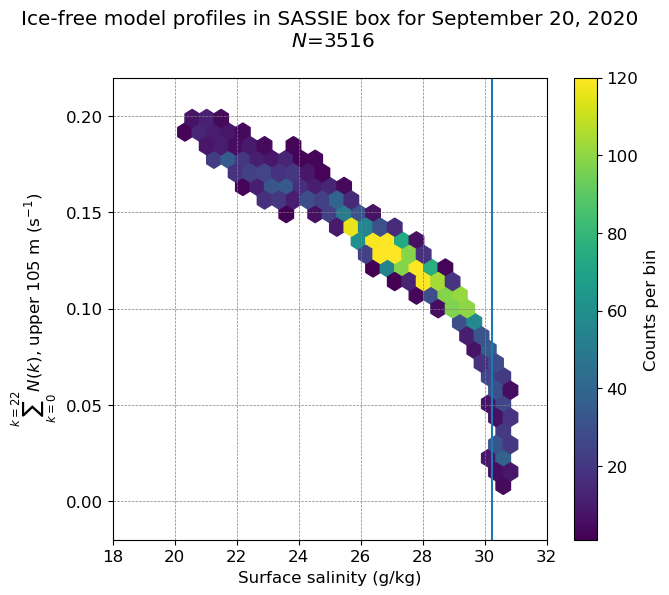

In [96]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

extent = [18,32,-0.02,0.22]
cbar_temp = ax.hexbin(sassie_box_profiles_surf.salinity,sum_N_upper105m, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=120)

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel(r'$\sum_{k=0}^{k=22} N(k)$, upper 105 m (s$^{-1}$)')
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Counts per bin');

ax.set_ylim(-0.02,0.22)
ax.set_xlim(18,32)
ax.axvline(x=30.25)

N = len(sum_N_upper105m.values[~np.isnan(sum_N_upper105m.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

### Plot points that are less than zero degrees C at the surface

In [166]:
sassie_box_profiles_surf_below0 = sassie_box_profiles_surf.where(sassie_box_profiles_surf.temperature<0)
sassie_box_profiles_below0 = sassie_box_profiles.where(sassie_box_profiles_surf.temperature<0)

In [167]:
# calculate sum of N in upper 100 meters

# select N2 values in this range, square root, and then take sum
sum_N_upper105m = np.sqrt(sassie_box_profiles.isel(depth_mid=slice(0,22)).N2.sum('depth_mid'))

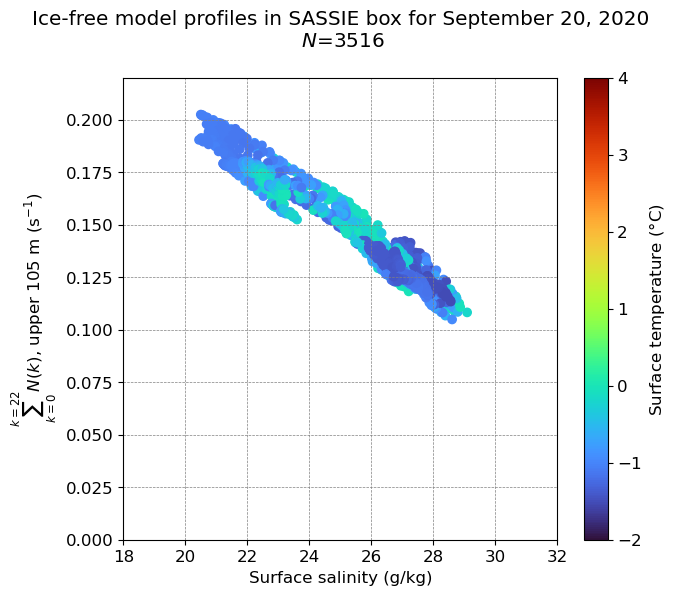

In [168]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf_below0.salinity,sum_N_upper105m,\
                       c=sassie_box_profiles_surf_below0.temperature,cmap='turbo',vmin=-2,vmax=4);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel(r'$\sum_{k=0}^{k=22} N(k)$, upper 105 m (s$^{-1}$)')
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(0,0.22)
ax.set_xlim(18,32)

N = len(sum_N_upper105m.values[~np.isnan(sum_N_upper105m.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

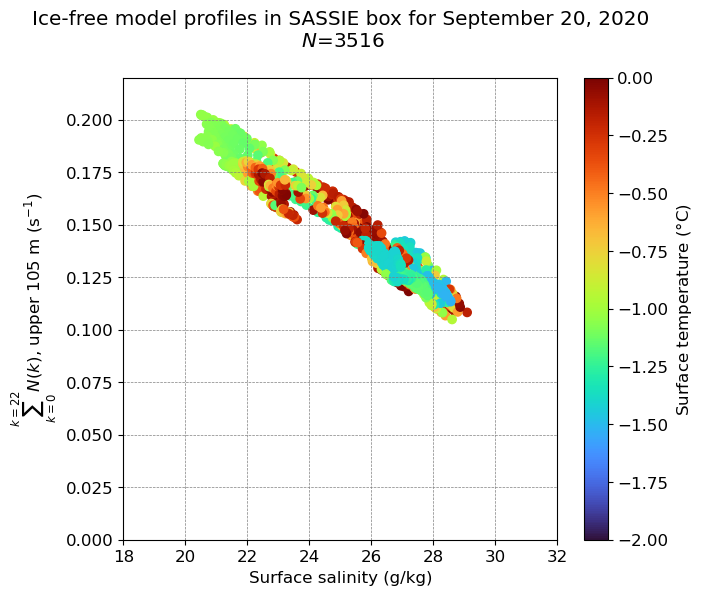

In [169]:
plt.rcParams.update({'font.size': 12})

# plot max buoyancy freq by SSS, colored by SST
fig, ax = plt.subplots(1,1,figsize=[7,6])

cbar_temp = ax.scatter(sassie_box_profiles_surf_below0.salinity,sum_N_upper105m,\
                       c=sassie_box_profiles_surf_below0.temperature,cmap='turbo',vmin=-2,vmax=0);

ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
ax.set_ylabel(r'$\sum_{k=0}^{k=22} N(k)$, upper 105 m (s$^{-1}$)')
ax.set_xlabel("Surface salinity (g/kg)")

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

ax.set_ylim(0,0.22)
ax.set_xlim(18,32)

N = len(sum_N_upper105m.values[~np.isnan(sum_N_upper105m.values)])
ax.set_title(f"Ice-free model profiles in SASSIE box for September 20, 2020\n $N$={N}",y=1.05);

### rotate map

In [41]:
# select beaufort region in less than 15% ice cover
beaufort_ocean_ds_wet = beaufort_ocean_ds.where(SI_day<15,np.nan)

In [51]:
# calculate sum of N in upper 100 meters
# select N2 values in this range, square root, and then take sum
sum_N_upper105m = np.sqrt(beaufort_ocean_ds_wet.isel(depth_mid=slice(0,22)).N2.sum('depth_mid'))

# calculate for entire region, not just ice free
sum_N_upper105m_all = np.sqrt(beaufort_ocean_ds.isel(depth_mid=slice(0,22)).N2.sum('depth_mid'))

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [52]:
# calculate sum of N in upper 100 meters
# select N2 values in this range, square root, and then take sum
sum_N_upper20m = np.sqrt(beaufort_ocean_ds_wet.isel(depth_mid=slice(0,10)).N2.sum('depth_mid'))

# calculate for entire region, not just ice free
sum_N_upper20m_all = np.sqrt(beaufort_ocean_ds.isel(depth_mid=slice(0,10)).N2.sum('depth_mid'))

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [59]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_beaufort.SIarea*100).sel(time='2020-09-20'),3,axes=[1,2]), dims=['time','i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(beaufort_ocean_ds.salinity.isel(k=0),3,axes=[0,1]), dims=['i','j'])
salt_beaufort_ice_free_flip = xr.DataArray(np.rot90(beaufort_ocean_ds.where(SI_day<15,np.nan).salinity.isel(k=0),3,axes=[0,1]), dims=['i','j'])

# N2 values
sum_N_upper20m_all_flip = xr.DataArray(np.rot90(sum_N_upper20m_all.where(sum_N_upper20m_all>0,np.nan),3,axes=[0,1]), dims=['i','j'])
sum_N_upper20m_flip = xr.DataArray(np.rot90(sum_N_upper20m.where(sum_N_upper20m>0,np.nan),3,axes=[0,1]), dims=['i','j'])

sum_N_upper105m_all_flip = xr.DataArray(np.rot90(sum_N_upper105m_all.where(sum_N_upper105m_all>0,np.nan),3,axes=[0,1]), dims=['i','j'])
sum_N_upper105m_flip = xr.DataArray(np.rot90(sum_N_upper105m.where(sum_N_upper105m>0,np.nan),3,axes=[0,1]), dims=['i','j'])

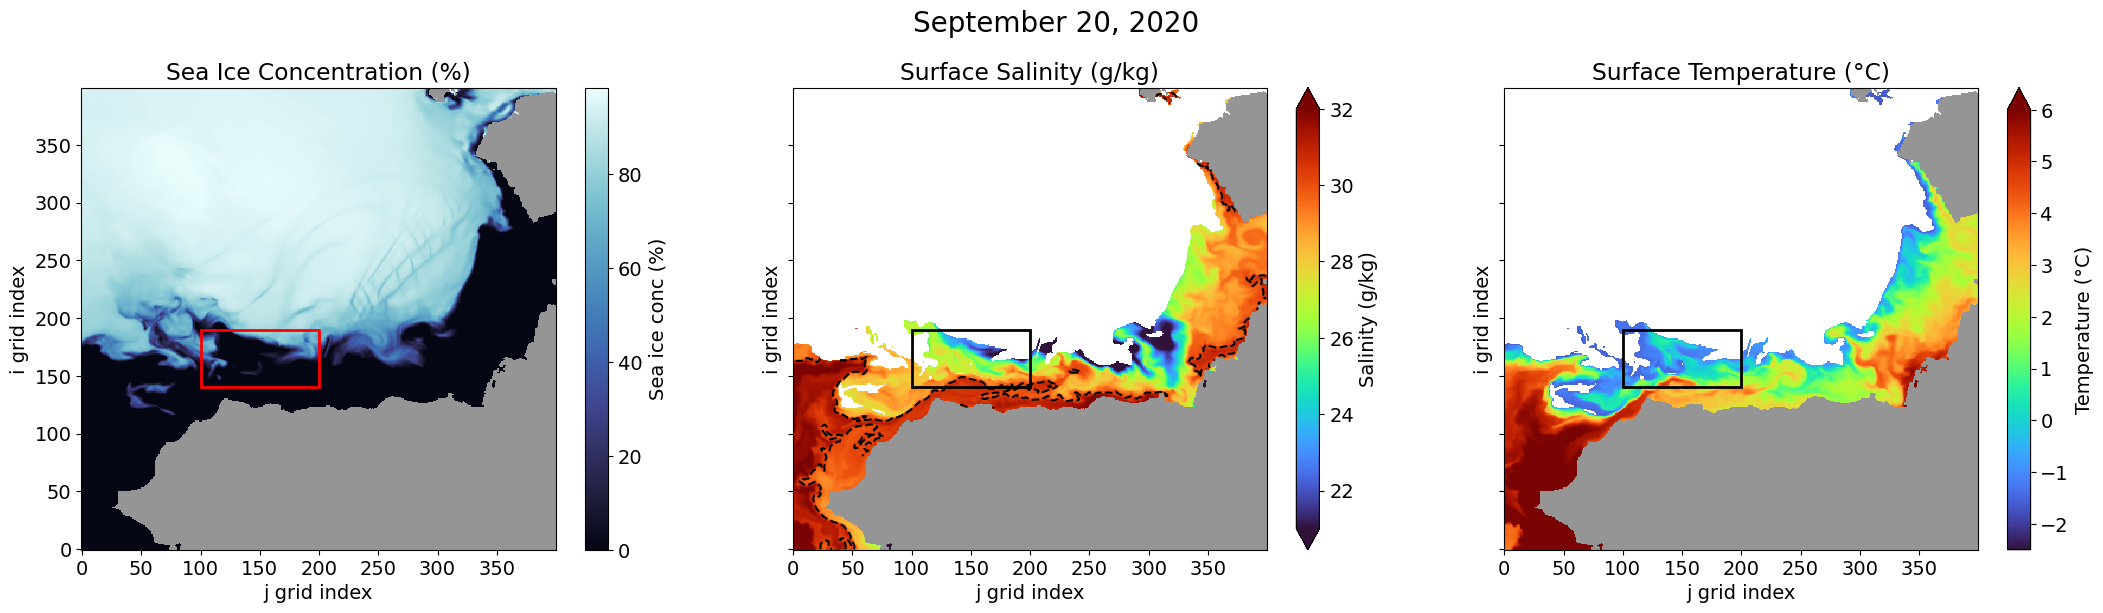

In [55]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[26,6],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_ice_free_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2.5,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});

salt_beaufort_ice_free_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("i grid index")
    ax.set_xlabel("j grid index")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='r', linestyle='solid', facecolor='none') # xy, width, height
ax1.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax2.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax3.add_patch(rect)

plt.suptitle("September 20, 2020",y=1.01,fontsize=20);

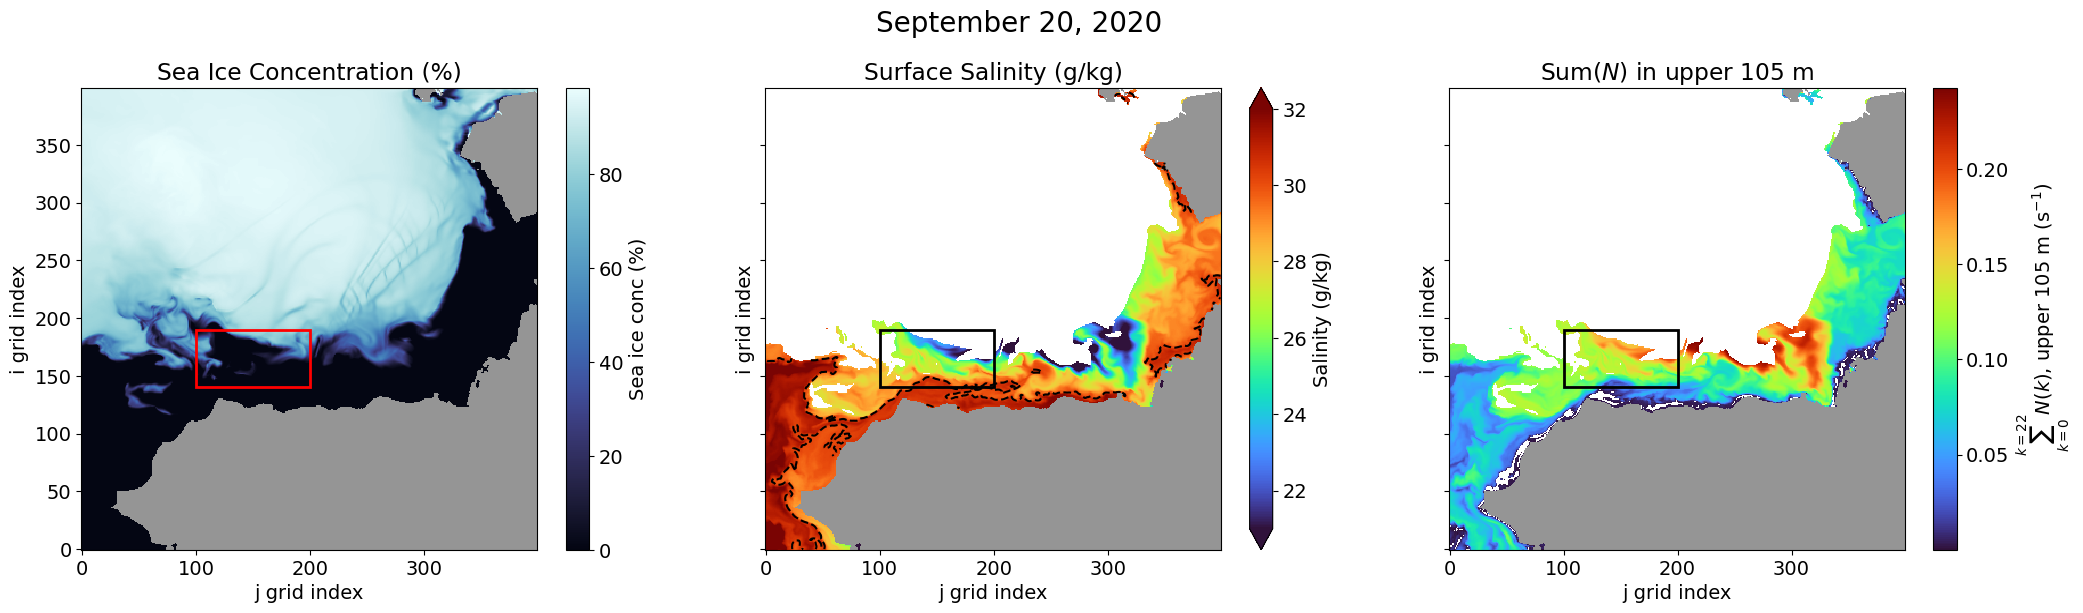

In [60]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[25,6],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_ice_free_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
sum_N_upper105m_flip.plot(ax=ax3,cmap='turbo',cbar_kwargs={'label': r'$\sum_{k=0}^{k=22} N(k)$, upper 105 m (s$^{-1}$)'});

salt_beaufort_ice_free_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("i grid index")
    ax.set_xlabel("j grid index")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Sum($N$) in upper 105 m");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='r', linestyle='solid', facecolor='none') # xy, width, height
ax1.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax2.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax3.add_patch(rect)

plt.suptitle("September 20, 2020",y=1.01,fontsize=20);

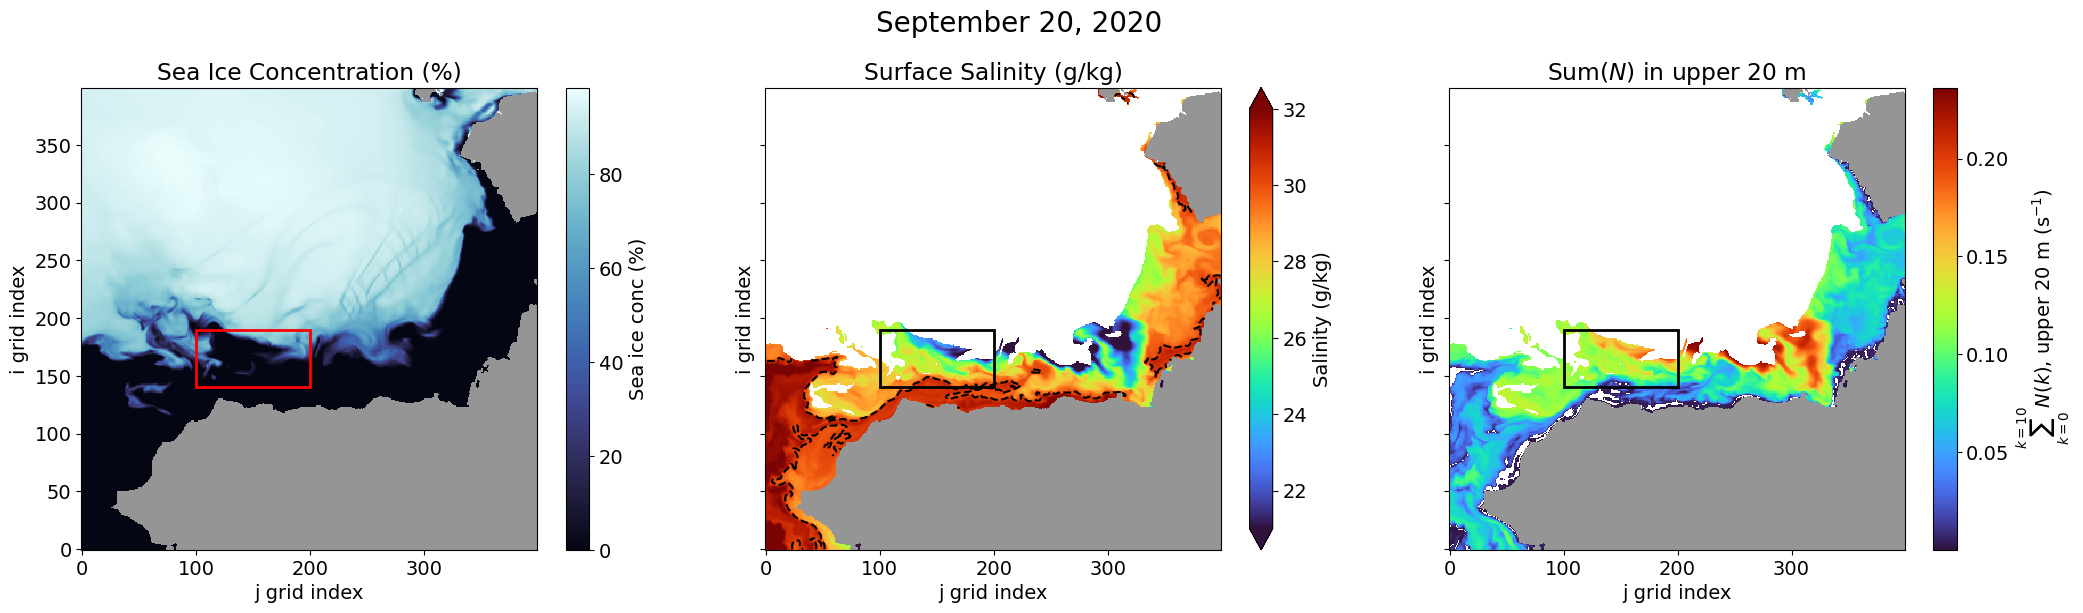

In [61]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[25,6],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_ice_free_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
sum_N_upper20m_flip.plot(ax=ax3,cmap='turbo',cbar_kwargs={'label': r'$\sum_{k=0}^{k=10} N(k)$, upper 20 m (s$^{-1}$)'});

salt_beaufort_ice_free_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("i grid index")
    ax.set_xlabel("j grid index")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Sum($N$) in upper 20 m");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='r', linestyle='solid', facecolor='none') # xy, width, height
ax1.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax2.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax3.add_patch(rect)

plt.suptitle("September 20, 2020",y=1.01,fontsize=20);

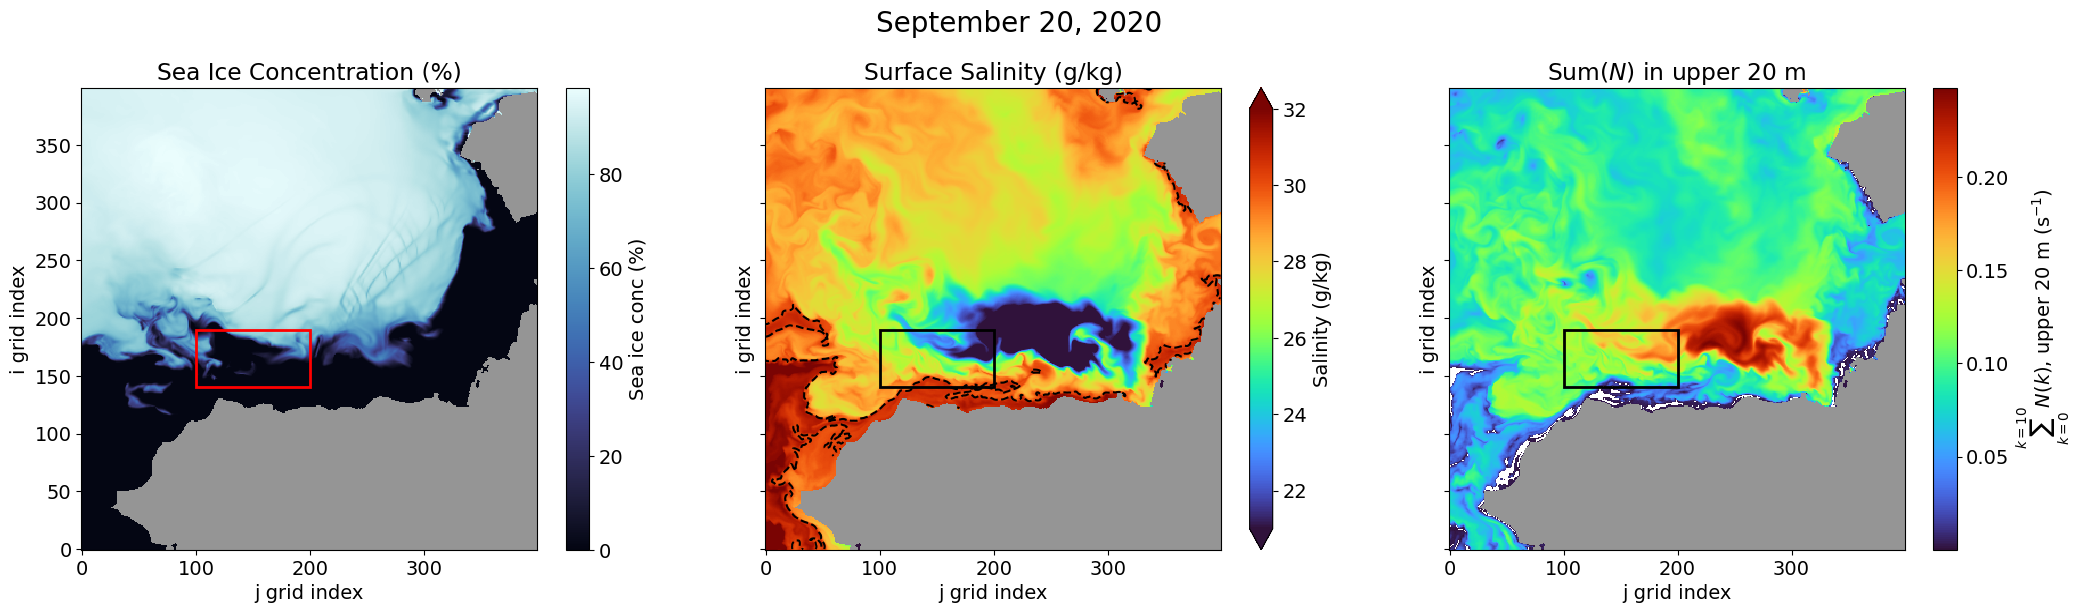

In [65]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[25,6],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
sum_N_upper20m_all_flip.plot(ax=ax3,cmap='turbo',cbar_kwargs={'label': r'$\sum_{k=0}^{k=10} N(k)$, upper 20 m (s$^{-1}$)'});

salt_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("i grid index")
    ax.set_xlabel("j grid index")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Sum($N$) in upper 20 m");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='r', linestyle='solid', facecolor='none') # xy, width, height
ax1.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax2.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax3.add_patch(rect)

plt.suptitle("September 20, 2020",y=1.01,fontsize=20);

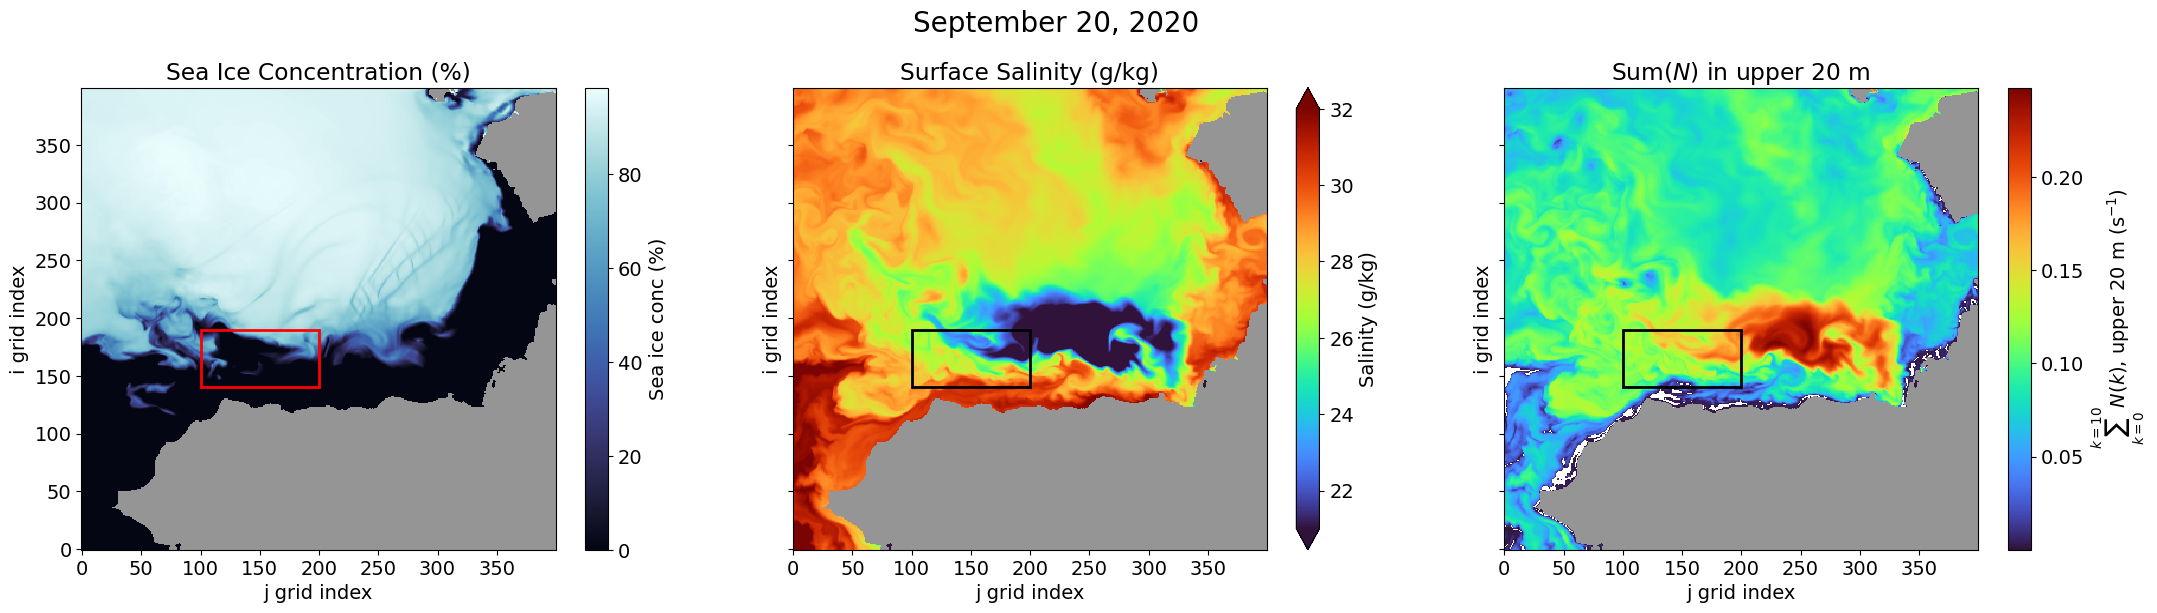

In [38]:
plt.rcParams.update({'font.size': 14})
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[26,6],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
N2_flip.plot(ax=ax3,cmap='turbo',cbar_kwargs={'label': r'$\sum_{k=0}^{k=10} N(k)$, upper 20 m (s$^{-1}$)'});

# beaufort_ocean_ds.where(SI_day<15,np.nan).salinity.isel(k=0).plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("i grid index")
    ax.set_xlabel("j grid index")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Sum($N$) in upper 20 m");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='r', linestyle='solid', facecolor='none') # xy, width, height
ax1.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax2.add_patch(rect)
rect = patches.Rectangle((100, 140), 100, 50, linewidth=2, edgecolor='k', linestyle='solid', facecolor='none') # xy, width, height
ax3.add_patch(rect)

plt.suptitle("September 20, 2020",y=1.01,fontsize=20);